## What this includes 

- The right correlation_graph (08.01.2026)

In [1]:
# Imports 

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patches
from pathlib import Path
import seaborn as sns

import matplotlib as mpl


import networkx as nx
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

from vizman import viz
viz.set_visual_style()
default_sizes = viz.load_data_from_json("sizes.json")
default_colors = viz.load_data_from_json("colors.json")
default_cmaps = viz.give_colormaps()

from src.visualization.one_simple_plot import plot_one_aesthetic_plot

from scipy.stats import entropy
# from skimage.measure import shannon_entropy

In [2]:
# Colors 

lecker_red = default_colors["warms"]["LECKER_RED"]
bone_white = default_colors["neutrals"]["BONE_WHITE"]
olive_gray = default_colors["neutrals"]["OLIVE_GRAY"]
halfblack = default_colors["neutrals"]["HALF_BLACK"]

# get the colors for -1 and 1
cmap = default_cmaps["db_bw_lr"].resampled(2)
color_neg1 = cmap(0)
color_pos1 = cmap(1)

black_white_map = plt.cm.colors.LinearSegmentedColormap.from_list(
        f'custom_cmap_black_white', 
        [
            bone_white,
            "black",
         ]
    )

# Get colormaps
dark2 = plt.get_cmap("Dark2")
set1 = plt.get_cmap("Set1")

# Extract colors
dark2_colors = list(dark2.colors)
set1_colors = [c for i, c in enumerate(set1.colors)] # if i != 4]

# Combine into one list
all_colors = dark2_colors + set1_colors
# remove index 13
all_colors.pop(13)

# reverse, just out of aesthetic preference
all_colors = all_colors[::-1]

# for i in range(len(all_colors)):
#     plt.plot([0, 1], [i, i], color=all_colors[i], linewidth=10)
#     plt.text(1.1, i, f"Color {i+1}", va='center')
# plt.xlim(0, 2)

In [3]:
# /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/05_mst_animal_0

In [4]:
dataset_name = "lexis_data" # hcp_schaefer_100_dataset" # lexis_data" # "suarez_MaMI_dataset"
experiment_name = "05_mst_animal_0" # 105_distance_metrics_mst_animal_0" # 05_mst_animal_0" # 02_ring_sweeps_animal_0" # 05_mst_animal_0" # 
# experiment_name = "02_ring_sweeps_animal_0" # "01_ring_sweep_animal_0" # "95_ring_seed_100_sweep_animal_206"
# experiment_name = "03_no_ring_sweeps_animal_0"
base_path = Path(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset_name}/{experiment_name}")
save_path = base_path / f"all_metrics_for_{experiment_name}.csv"


filtering_df_path = base_path / f"all_metrics_for_{experiment_name}.csv" # _updated.csv"
filtering_df = pd.read_csv(filtering_df_path)

output_path = Path(base_path) / "figures_manuscript_apdx"
output_path.mkdir(exist_ok=True)

In [5]:
# Get the name of all measures
all_dist_measures = [
#     "energy", 
#     # "energy_w_o_gnm_library", 
#     "portrait", 
#     "spectral_distance_adjacency",
#     "spectral_distance_norm_laplacian", 
    
#     "communicability_corr",
#     "communicability_jsd",
#     "network_mutual_information",
#     "dc_network_mutual_information", 
    
#     "net_simile", 
#     "netrd_non_backtracking_spectral", 
#     "resistance", 
#     "delta_con", 
    
#     "f1", 
#     # "f1_dist", 
#     "hamming",
#     "frobenius", 
#     "jaccard", 
# ]

##### USE ORDER THAT ALSO THE HCP DATASET USES: ADDED THAT FOR APDX DATA
    "portrait",
    "energy",
    "spectral_distance_norm_laplacian",
    "spectral_distance_adjacency",
    "net_simile",
    "frobenius",
    "hamming",
    "delta_con",
    "resistance",
    "netrd_non_backtracking_spectral",
    "communicability_jsd",
    "jaccard",
    "f1",
    "network_mutual_information",
    "dc_network_mutual_information",
    "communicability_corr"
]

In [6]:
# Method names for plotting

method_names = {
    'portrait': 'Portrait', #  Divergence',
    'energy': 'Energy', #  Distance',
        'energy_w_o_gnm_library': 'Energy (w/o GNM lib)', #  Distance',
        'spectral_distance': 'Spectral Distance', # Different versions?? 
    'spectral_distance_laplacian': 'Spectral (Laplacian)',
    'spectral_distance_norm_laplacian': 'Spectral (Normalized Laplacian)',
    'spectral_distance_adjacency': 'Spectral (Adjacency)',
    'f1': 'F1', #  Score',
        'f1_dist': 'F1 Distance', #  Distance',
    'hamming': 'Hamming', # Distance',
        'communicability': 'Communicability Correlation', #  Distance',
        'graph_kernel': 'Graph Kernel Distance old',
        'multiplex_layer_similarity': 'Multiplex Layer Similarity',
    'cosine_embedding': 'Cosine Embedding', #  Distance',
    'graph_edit_distance': 'Graph Edit', #  Distance',
    'network_mutual_information': 'Network Mutual Information',
    'dc_network_mutual_information': 'DC Network Mutual Information',
        'hungarian_alignment': 'Hungarian Alignment',
    'graph_kernel_networkx': 'Graph Kernel', #  Distance',
    'delta_con': 'DeltaCon',
    'delta_con_distance': 'DeltaCon (distance)', # Distance',
        'resistance_distance': 'Resistance old', #  Distance',
        'wasserstein_gromov': 'Wasserstein-Gromov Distance',
    'wasserstein_sinkhorn': 'Wasserstein-Sinkhorn', #  Distance',

        'edit_distance': 'Edit Distance old',
    'communicability_corr': 'Communicability Correlation',
    'communicability_mse': 'Communicability MSE',
    'communicability_jsd': 'Communicability JSD',
    'frobenius': 'Frobenius', #  Distance',
    'jaccard': 'Jaccard', #  Distance',

    'resistance': 'Resistance', #  Distance',
    'net_simile': 'NetSimile', #  Distance',
    # 'net_smile': 'NetSimile', #  Distance', # !!!! Typo, remove this later (after 05 it should be fixed)
    'net_lsd': 'NetLSD', #  Distance',
    'quantum_jsd': 'Quantum JSD', #  Distance',
    'graph_diffusion': 'Graph Diffusion', #  Distance',
    'polynomial_dissimilarity': 'Polynomial Dissimilarity', #  Distance',
    'degree_divergence': 'Degree Divergence', #  Distance',
    'onion_divergence': 'Onion Divergence', #  Distance',

    "network_mutual_information_old": "Network Mutual Information old",
    "netrd_deltacon": "NetRD DeltaCon",
    "netrd_communicability_jsd": "NetRD Communicability JSD",
    "distributional_nbd": "Distributional NBD",
    "dk_series": "DK Series",
    "d_measure": "D Measure",
    "netrd_frobenius": "NetRD Frobenius",
    "netrd_hamming": "NetRD Hamming",
    "hamming_ipsen_mikhailov": "Hamming Ipsen-Mikhailov",
    "ipsen_mikhailov": "Ipsen-Mikhailov",
    "netrd_jaccard": "NetRD Jaccard",
    "netrd_laplacian_spectral": "NetRD Laplacian Spectral",
    "netrd_non_backtracking_spectral": "Spectral (Non-Backtracking)", # NetRD Non-Backtracking Spectral",
    "netrd_portrait_divergence": "NetRD Portrait Divergence",
}


In [7]:
# Get values for every measure

matrices_of_metrics = {}

for idx, mode in enumerate(all_dist_measures):

    path = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset_name}/{experiment_name}/summary_indiv_{mode}_for_exp_{experiment_name}.csv"
    df = pd.read_csv(path)
    
    # Get the metric column
    metric_col = [col for col in df.columns if col not in ["eta", "gamma", "network_index", "filename", "id"]]
    if not metric_col:
        raise ValueError(f"No metric column found in {df.columns}")
    
    # Round eta and gamma to a reasonable number of decimal places (e.g., 2 or 3)
    df['eta'] = df['eta'].round(2)
    df['gamma'] = df['gamma'].round(2)
    filtering_df['eta'] = filtering_df['eta'].round(2)
    filtering_df['gamma'] = filtering_df['gamma'].round(2)

    # Now merge
    if "no" in experiment_name: # FILTER BY NUMBER COMPONENTS. Alternative: not "ring" in experiment_name:
        df = df.merge(filtering_df[['eta', 'gamma', 'n_connected_components']], 
                    on=['eta', 'gamma'], 
                    how='left')
        # Filter
        df = df[df['n_connected_components'] <= 1]
    
    else: 
        df = df.merge(filtering_df[['eta', 'gamma']], 
                    on=['eta', 'gamma'], 
                    how='left')



    # Turn df into a pivot table. If there are multiple values for one eta-gamma pair, take the mean
    df_pivot = df.pivot_table(index='gamma', columns='eta', values=metric_col[0], aggfunc='mean')

    # Min-max normalize the values to [0, 1]
    df_pivot = (df_pivot - df_pivot.min().min()) / (df_pivot.max().max() - df_pivot.min().min())
    
    # Store the matrix as a numpy array
    matrix = df_pivot.values[::-1]
    if mode in ["f1", 
                    "f1_dist",
                "multiplex_layer_similarity", 
                "jaccard", 
                # "communicability_jsd", 
                "communicability_corr",
                "network_mutual_information", 
                "dc_network_mutual_information", 
            ]: # TODO: WHICH OTHER SIMILARITY METRICS? 
        matrix = 1 - matrix  # Invert for similarity measures

    # if mode == "resistance":
    #     matrix = np.log1p(matrix)  # Apply log1p transformation
        
    matrices_of_metrics[mode] = matrix


# Other stuff

In [8]:
# Functions: Correlation matrix, clustering, reordering
def load_method_data(method):
    """Load data for a specific method."""
    path = f"{base_path}/summary_indiv_{method}_for_exp_{experiment_name}.csv"
    try:
        df = pd.read_csv(path)
        metric_cols = [col for col in df.columns 
                      if col not in ["eta", "gamma", "network_index", "filename", "id"]]
        if metric_cols:
            df['metric_value'] = df[metric_cols[0]]
            df['method'] = method
            return df[['eta', 'gamma', 'id', 'metric_value', 'method']]
        return None
    except FileNotFoundError:
        print(f"Warning: File not found for method {method}")
        return None

def calculate_ground_truth(all_data):
    """Calculate approximated ground truth as max across methods for each eta-gamma-id."""
    ground_truth = all_data.groupby(['eta', 'gamma', 'id'])['metric_value'].max().reset_index()
    ground_truth.rename(columns={'metric_value': 'approximated_ground_truth'}, inplace=True)
    return ground_truth

def create_full_dataset(all_data, ground_truth):
    """Create dataset with all methods and ground truth."""
    pivot_data = all_data.pivot_table(
        index=['eta', 'gamma', 'id'],
        columns='method',
        values='metric_value'
    ).reset_index()
    
    if ground_truth is not None:
        full_data = pivot_data.merge(ground_truth, on=['eta', 'gamma', 'id'])
    else: 
        full_data = pivot_data
    return full_data

def calculate_correlation_matrix(full_data, methods):
    """Calculate Pearson correlation matrix between methods and ground truth."""
    cols_to_correlate = methods # + ['approximated_ground_truth']
    corr_matrix = full_data[cols_to_correlate].corr(method='pearson')
    return corr_matrix

def cluster_correlation_matrix(corr_matrix):
    """
    Cluster the correlation matrix using hierarchical clustering.
    Returns the reordered correlation matrix and the order of items.
    """
    # Convert correlation to distance
    # Use 1 - correlation for positive correlations (closer to 1 = more similar)
    distance_matrix = 1 - corr_matrix.values
    
    # Ensure all values are non-negative and clip to avoid numerical issues
    distance_matrix = np.clip(distance_matrix, 0, 2)
    
    # Make sure the matrix is symmetric
    distance_matrix = (distance_matrix + distance_matrix.T) / 2
    
    # Set diagonal to 0
    np.fill_diagonal(distance_matrix, 0)
    
    # Convert to condensed distance matrix
    condensed_dist = squareform(distance_matrix, checks=False)
    
    # Replace any NaN or inf values
    condensed_dist = np.nan_to_num(condensed_dist, nan=1.0, posinf=2.0, neginf=0.0)
    
    # Perform hierarchical clustering
    linkage_matrix = linkage(condensed_dist, method='average')  # Changed to 'average' which is more robust
    
    # Get the order from the dendrogram
    dendro = dendrogram(linkage_matrix, no_plot=True)
    order = dendro['leaves']

    # Reorder the correlation matrix
    ordered_corr = corr_matrix.iloc[order, order]
    
    return ordered_corr, order, linkage_matrix


In [9]:
print("Loading method data...")
all_data_list = []
loaded_methods = []

for method in all_dist_measures:
    df = load_method_data(method)
    if df is not None:
        all_data_list.append(df)
        loaded_methods.append(method)
        print(f"Loaded {method}: {len(df)} rows")
    
all_data = pd.concat(all_data_list, ignore_index=True)

full_data = create_full_dataset(all_data, ground_truth=None)
corr_matrix = calculate_correlation_matrix(full_data, loaded_methods)

corr_path = output_path / 'correlation_matrix.csv'
corr_matrix.to_csv(corr_path)


# Cluster the correlation matrix
clustered_corr, order, linkage_matrix = cluster_correlation_matrix(corr_matrix)

# Reorder all_methods based on clustering: REMOVED THAT FOR APDX DATA
# all_dist_measures = [all_dist_measures[i] for i in order]  

Loading method data...
Loaded portrait: 25000 rows
Loaded energy: 25000 rows
Loaded spectral_distance_norm_laplacian: 25000 rows
Loaded spectral_distance_adjacency: 25000 rows
Loaded net_simile: 25000 rows
Loaded frobenius: 25000 rows
Loaded hamming: 25000 rows
Loaded delta_con: 25000 rows
Loaded resistance: 25000 rows
Loaded netrd_non_backtracking_spectral: 25000 rows
Loaded communicability_jsd: 25000 rows
Loaded jaccard: 25000 rows
Loaded f1: 25000 rows
Loaded network_mutual_information: 25000 rows
Loaded dc_network_mutual_information: 25000 rows
Loaded communicability_corr: 25000 rows


# Further grid plots

In [10]:
metric_colors = {}

for i, metric_name in enumerate(all_dist_measures):
        metric_colors[metric_name] = all_colors[i]
        
        
metric_colors

{'portrait': (0.6, 0.6, 0.6),
 'energy': (0.9686274509803922, 0.5058823529411764, 0.7490196078431373),
 'spectral_distance_norm_laplacian': (0.6509803921568628,
  0.33725490196078434,
  0.1568627450980392),
 'spectral_distance_adjacency': (1.0, 0.4980392156862745, 0.0),
 'net_simile': (0.596078431372549, 0.3058823529411765, 0.6392156862745098),
 'frobenius': (0.30196078431372547, 0.6862745098039216, 0.2901960784313726),
 'hamming': (0.21568627450980393, 0.49411764705882355, 0.7215686274509804),
 'delta_con': (0.8941176470588236, 0.10196078431372549, 0.10980392156862745),
 'resistance': (0.4, 0.4, 0.4),
 'netrd_non_backtracking_spectral': (0.6509803921568628,
  0.4627450980392157,
  0.11372549019607843),
 'communicability_jsd': (0.9019607843137255,
  0.6705882352941176,
  0.00784313725490196),
 'jaccard': (0.4, 0.6509803921568628, 0.11764705882352941),
 'f1': (0.9058823529411765, 0.1607843137254902, 0.5411764705882353),
 'network_mutual_information': (0.4588235294117647,
  0.43921568627

In [11]:
# n_methods = len(all_dist_measures)
# n_cols = 4
# n_rows = int(np.ceil(n_methods / n_cols))

# # Calculate height to maintain roughly square subplots
# height = 18 * (n_rows / n_cols) # * 0.9 # 0.9 is random factor for colorbar

# fig, axes = plt.subplots(n_rows, n_cols, 
#                             figsize=viz.cm_to_inch((18, height)), 
#                             dpi=150,
#                             sharex=True, 
#                             sharey=True)

# axes = axes.flatten()

# for idx, mode in enumerate(all_dist_measures):
#     ax = axes[idx]
    
#     # matrices_of_metrics[mode]
#     # Create scatter plot
#     # scatter = ax.scatter(df["eta"], df["gamma"], 
#     #                     c=df[metric_col[0]], 
#     #                     cmap=default_cmaps["metric_purple_beige"], 
#     #                     s=2.4)
    
#     # create cmap from metric_colors: going from bone_white to metric_colors[mode]
#     # cmap = "cividis" 
#     cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
#         f'custom_cmap_{mode}', 
#         [metric_colors[mode], "black"
#          # bone_white, 
#         ]
#     )

#     scatter = ax.imshow(np.log(matrices_of_metrics[mode]), 
#                         cmap=cmap, 
#                        aspect='auto',
#                     #    origin='lower',
#                        extent=[
#                            df["eta"].min(), df["eta"].max(),
#                            df["gamma"].min(), df["gamma"].max()
#                        ])
    
#     # ax.set_xlim(-8, 3)
#     # ax.set_ylim(-0.1, 1)
    
#     # Set ticks
#     ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
#     ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
    
#     # Add title for each subplot
#     print(mode)
#     title = method_names[mode] # f"{metric_col[0].split('subject')[0].replace('_', ' ').capitalize()}"
#     ax.set_title(title, fontsize=8)
    
#     # # Add colorbar for each subplot
#     # cbar = plt.colorbar(scatter, ax=ax)
#     # cbar.ax.tick_params(labelsize=6)
    
#     # Only add labels to edge subplots
#     if idx % n_cols == 0:  # Left column
#         ax.set_ylabel(r"$\gamma$")
#     if idx >= n_methods - n_cols:  # Bottom row
#         ax.set_xlabel(r"$\eta$")

# # Hide unused subplots
# for idx in range(n_methods, len(axes)):
#     axes[idx].axis('off')

# # Add one shared colorbar below all subplots
# cbar_ax = fig.add_axes([0.25, 0.0, 0.5, 0.01])  # [left, bottom, width, height]
# cbar = fig.colorbar(scatter, cax=cbar_ax, orientation='horizontal')
# cbar.set_label("Darker: More similar. Lighter: Less similar")
# cbar.ax.tick_params(labelsize=8)
# plt.tight_layout()

In [12]:
    # n_methods = len(all_dist_measures)
    # n_cols = 4
    # n_rows = int(np.ceil(n_methods / n_cols))

    # # Calculate height to maintain roughly square subplots
    # height = 18 * (n_rows / n_cols) # * 0.9 # 0.9 is random factor for colorbar

    # fig, axes = plt.subplots(n_rows, n_cols, 
    #                             figsize=viz.cm_to_inch((18, height)), 
    #                             dpi=150,
    #                             sharex=True, 
    #                             sharey=True)

    # axes = axes.flatten()

    # for idx, mode in enumerate(all_dist_measures):
    #     ax = axes[idx]
        
    #     cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
    #         f'custom_cmap_{mode}', 
    #         [
    #             "black",
    #             # metric_colors[mode], 
    #             # "white", 
    #             bone_white
    #         #  
    #         #  color_neg1,
    #         #  halfblack, 
    #         #  bone_white, 
    #         ]
    #     )
    #     # cmap = default_cmaps["metric_purple_beige"]

    #     scatter = ax.imshow(np.log(matrices_of_metrics[mode]), # matrices_of_metrics[mode], 
    #                         cmap=cmap, 
    #                     aspect='auto',
    #                     #    origin='lower',
    #                     extent=[
    #                         df["eta"].min(), df["eta"].max(),
    #                         df["gamma"].min(), df["gamma"].max()
    #                     ])
        
    #     # Set ticks
    #     ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
    #     ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
        
    #     # Add title for each subplot
    #     print(mode)
    #     title = method_names[mode] # f"{metric_col[0].split('subject')[0].replace('_', ' ').capitalize()}"
    #     ax.set_title(title, fontsize=8)
        
    #     # # Add colorbar for each subplot
    #     # cbar = plt.colorbar(scatter, ax=ax)
    #     # cbar.ax.tick_params(labelsize=6)
        
    #     # Only add labels to edge subplots
    #     if idx % n_cols == 0:  # Left column
    #         ax.set_ylabel(r"$\gamma$")
    #     if idx >= n_methods - n_cols:  # Bottom row
    #         ax.set_xlabel(r"$\eta$")

    # # Hide unused subplots
    # for idx in range(n_methods, len(axes)):
    #     axes[idx].axis('off')

    # # Add one shared colorbar below all subplots
    # cbar_ax = fig.add_axes([0.25, 0.0, 0.5, 0.01])  # [left, bottom, width, height]
    # cbar = fig.colorbar(scatter, cax=cbar_ax, orientation='horizontal')
    # cbar.set_label("Darker: More similar. Lighter: Less similar")
    # cbar.ax.tick_params(labelsize=8)
    # plt.tight_layout()

    # plt.savefig(output_path / "all_similarity_plots_grayscale.pdf")
    # print(output_path / "all_similarity_plots_grayscale.pdf")

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_93857/974741575.py:68: RuntimeWarning: divide by zero encountered in log
  scatter = ax.imshow(np.log(matrices_of_metrics[mode]), # matrices_of_metrics[mode],
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_93857/974741575.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


portrait
energy
spectral_distance_norm_laplacian
spectral_distance_adjacency
net_simile
frobenius
hamming
delta_con
resistance
netrd_non_backtracking_spectral
communicability_jsd
jaccard
f1
network_mutual_information
dc_network_mutual_information
communicability_corr
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/05_mst_animal_0/figures_manuscript_apdx/sixteen_similarity_plots_grayscale_log_with_x_eq_0.pdf


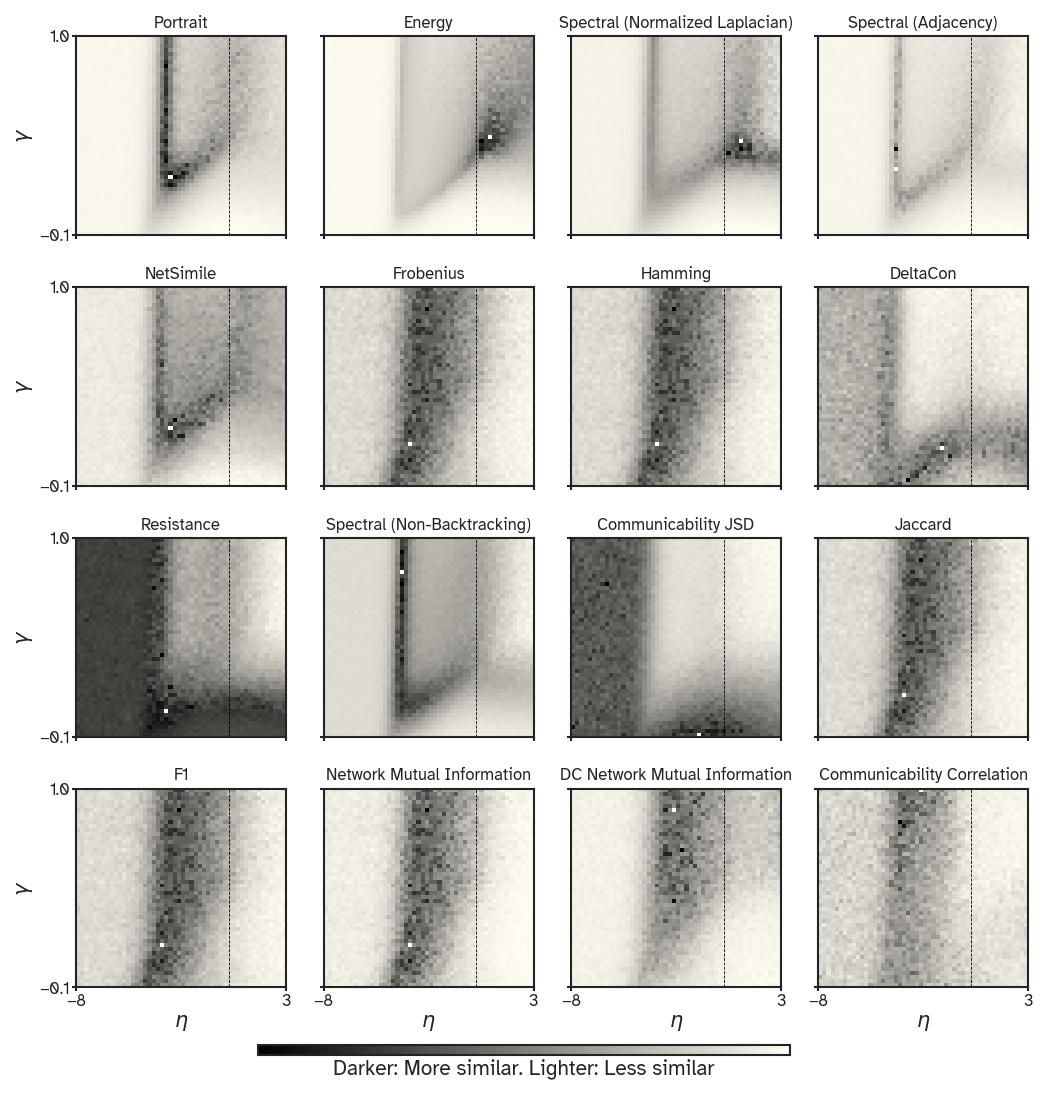

In [13]:
all_dist_measures = all_dist_measures # [
#         "energy",
#         "f1", # "one_minus_f1", 
#         "portrait", 
#         "delta_con", 
#         "spectral_distance",
#         "edit_distance", 
#             "graph_edit_distance", # braucht ewig 
#             "network_mutual_information", 
#         "wasserstein_gromov",
#         "graph_kernel_networkx", 
#         "communicability_jsd", 
#         "frobenius", 
#         "jaccard", # one_minus_jaccard", 
         
        
#         # "f1", 
#         "multiplex_layer_similarity", # one_minus_multiplex_layer_similarity",
#         # "jaccard", 
#         # "communicability", 
#         "cosine_embedding", 
#         # "wasserstein_sinkhorn", 
#         "hungarian_alignment", 
#         # "graph_kernel", 
        
#         # "resistance_distance", 
        
#         # "graph_edit_distance", 
#         # "network_mutual_information", 
#         # "communicability_mse", 
        
        
# ]
        
n_methods = len(all_dist_measures)
n_cols = 4
n_rows = int(np.ceil(n_methods / n_cols))

# Calculate height to maintain roughly square subplots
height = 18 * (n_rows / n_cols) # * 0.9 # 0.9 is random factor for colorbar

fig, axes = plt.subplots(n_rows, n_cols, 
                            figsize=viz.cm_to_inch((18, height)), 
                            dpi=150,
                            sharex=True, 
                            sharey=True)

axes = axes.flatten()

for idx, mode in enumerate(all_dist_measures):
    ax = axes[idx]
    
    cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
        f'custom_cmap_{mode}', 
        [
            "black",
            # metric_colors[mode], 
            # "white", 
            bone_white
        #  
        #  color_neg1,
        #  halfblack, 
        #  bone_white, 
         ]
    )
    # cmap = default_cmaps["metric_purple_beige"]

    scatter = ax.imshow(np.log(matrices_of_metrics[mode]), # matrices_of_metrics[mode], 
                        cmap=cmap, 
                       aspect='auto',
                    #    origin='lower',
                       extent=[
                           df["eta"].min(), df["eta"].max(),
                           df["gamma"].min(), df["gamma"].max()
                       ])
    
    # ax.set_xlim(-8, 3)
    # ax.set_ylim(-0.1, 1)
    
    # Set ticks
    ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
    ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])

    ax.vlines(x=0, 
              ymin=df["gamma"].min(), ymax=df["gamma"].max(), 
              color='black', linestyle='--', linewidth=0.4)
    
    # Add title for each subplot
    print(mode)
    title = method_names[mode] # f"{metric_col[0].split('subject')[0].replace('_', ' ').capitalize()}"
    ax.set_title(title, fontsize=8)
    
    # # Add colorbar for each subplot
    # cbar = plt.colorbar(scatter, ax=ax)
    # cbar.ax.tick_params(labelsize=6)
    
    # Only add labels to edge subplots
    if idx % n_cols == 0:  # Left column
        ax.set_ylabel(r"$\gamma$")
    if idx >= n_methods - n_cols:  # Bottom row
        ax.set_xlabel(r"$\eta$")

# Hide unused subplots
for idx in range(n_methods, len(axes)):
    axes[idx].axis('off')

# Add one shared colorbar below all subplots
cbar_ax = fig.add_axes([0.25, 0.0, 0.5, 0.01])  # [left, bottom, width, height]
cbar = fig.colorbar(scatter, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Darker: More similar. Lighter: Less similar")
cbar.ax.tick_params(labelsize=8)
cbar.set_ticks([])  # Remove ticks
plt.tight_layout()

plt.savefig(output_path / "sixteen_similarity_plots_grayscale_log_with_x_eq_0.pdf")
print(output_path / "sixteen_similarity_plots_grayscale_log_with_x_eq_0.pdf")

In [14]:
all_dist_measures = all_dist_measures

In [15]:
all_dist_measures = all_dist_measures # ["energy", "spectral_distance", "portrait", "graph_kernel_networkx", "communicability_jsd", "delta_con"]


# Timing 

number dots: 25000
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/05_mst_animal_0/figures_manuscript_apdx/similarity_methods_timing_comparison.pdf


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_93857/553924641.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(timing_data,


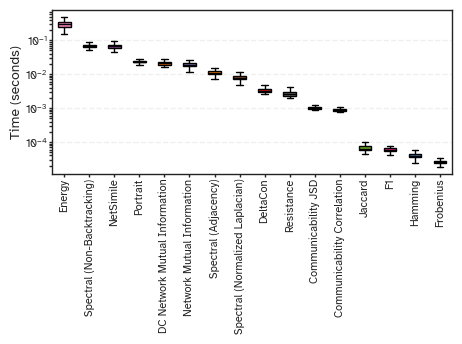

In [16]:
timing_data = []
method_labels = []
method_key_names_ordered = []

for method in all_dist_measures:
    # Construct the timing file path
    timing_file = Path(base_path) / f"timing_{method}_for_exp_{experiment_name}.csv"
    
    # Check if file exists
    if not timing_file.exists():
        print(f"Warning: File not found - {timing_file}")
        continue
    
    # Read timing data
    df = pd.read_csv(timing_file) # ALL dots! 
    # df = pd.read_csv(timing_file)[:2500]
    
    # Find the timing column
    timing_col = None
    for col in df.columns:
        if any(keyword in col.lower() for keyword in ['time']):
            timing_col = col
            break
    
    # Extract timing values
    timings = df[timing_col].dropna().values
    
    if len(timings) > 0:
        timing_data.append(timings)
        method_labels.append(method_names[method]) # .replace("_", " ").title())

# Order methods by median timing
# if order_by_median:
median_timings = [np.median(data) for data in timing_data]
sorted_indices = np.argsort(median_timings)[::-1]
timing_data = [timing_data[i] for i in sorted_indices]
method_labels = [method_labels[i] for i in sorted_indices]
method_key_names_ordered = [all_dist_measures[i] for i in sorted_indices]

print("number dots:", len(timing_data[0]))
# Create boxplot
plt.figure(figsize=viz.cm_to_inch((12,9))) # (8, 8))

bp = plt.boxplot(timing_data, 
                labels=method_labels,
                patch_artist=True,
                showmeans=False, # True,
                showfliers=False, # True, # False, 
                ) 

# Customize appearance
for patch, color in zip(bp['boxes'], [metric_colors[method] for method in method_key_names_ordered]):
    patch.set_facecolor(color)


# Change median lines to black
for median in bp['medians']:
    median.set_color('black')


plt.ylabel('Time (seconds)') 
    # plt.xticks([]) 
plt.xticks(rotation=90) 
plt.yscale('log')
# # Add grid for better readability
plt.gca().yaxis.grid(True, alpha=0.3, linestyle='--')
plt.gca().set_axisbelow(True)


plt.tight_layout()

plt.savefig(output_path / "similarity_methods_timing_comparison.pdf")
print(output_path / "similarity_methods_timing_comparison.pdf")


# Correlation Matrix 

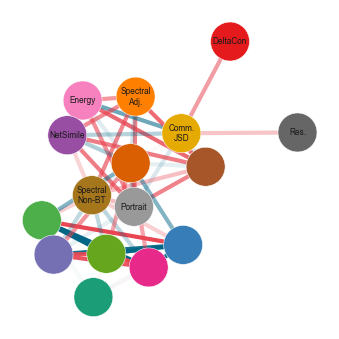

Saved correlation network to /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/05_mst_animal_0/all_metrics_for_05_mst_animal_0.csv
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/05_mst_animal_0/correlation_graph.pdf


In [17]:

"""
Create a network graph where methods are nodes and correlations are edges.
Uses hierarchical clustering to position nodes.
"""


from scipy.cluster.hierarchy import fcluster



selected_methods = [
    "energy", 
    "portrait",
    "spectral_distance_adjacency",
    # "spectral_distance_norm_laplacian", 
    
    # "communicability_corr",
    "communicability_jsd",
    # "network_mutual_information",
    # "dc_network_mutual_information", 
    
    "net_simile", 
    "netrd_non_backtracking_spectral", 
    "resistance", 
    "delta_con", 
    
    # "f1", 
    # "hamming",
    # "frobenius", 
    # "jaccard", 
]

save_folder=save_path
threshold=0.5


# Get clustering information
clustered_corr, order, linkage_matrix = cluster_correlation_matrix(corr_matrix)

# Extract communities (adjust t parameter to control number of clusters)
communities = fcluster(linkage_matrix, t=5, # 2, # 1.5, 
                        criterion='distance')

# Create graph
G = nx.Graph()
methods = corr_matrix.columns.tolist()
G.add_nodes_from(methods)

# Add edges for correlations above threshold
for i, method1 in enumerate(methods):
    for j, method2 in enumerate(methods):
        if i < j:
            corr_value = corr_matrix.loc[method1, method2]
            if not np.isnan(corr_value) and abs(corr_value) >= threshold:
                G.add_edge(method1, method2, weight=abs(corr_value), 
                            correlation=corr_value)

# Create community-informed layout
# First, get positions for each community center
unique_communities = np.unique(communities)
n_communities = len(unique_communities)

# Place community centers in a circle
community_centers = {}
for i, comm in enumerate(unique_communities):
    angle = 2 * np.pi * i / n_communities
    community_centers[comm] = np.array([np.cos(angle), np.sin(angle)]) * 3


np.random.seed(0)  # For reproducibility
# Initialize positions based on community membership
initial_pos = {}
for method, comm in zip(methods, communities):
    # Add small random offset within community
    offset = np.random.randn(2) * 0.3
    initial_pos[method] = community_centers[comm] + offset


def separate_overlapping_nodes(pos, node_radius=0.3, max_iter=100):
    """
    Ensure all nodes are at least 2 * node_radius apart.
    pos: dict of node -> np.array([x, y])
    node_radius: radius of each node
    max_iter: maximum adjustment iterations
    """
    nodes = list(pos.keys())
    positions = pos.copy()
    min_dist = 2 * node_radius  # minimum distance between centers

    for _ in range(max_iter):
        moved = False
        for i, n1 in enumerate(nodes):
            for j, n2 in enumerate(nodes):
                if i >= j:
                    continue
                delta = positions[n2] - positions[n1]
                dist = np.linalg.norm(delta)
                if dist < min_dist and dist > 0:
                    # push nodes apart
                    shift = (min_dist - dist) / 2
                    positions[n1] -= shift * delta / dist
                    positions[n2] += shift * delta / dist
                    moved = True
        if not moved:
            break

    return positions

# def adjust_node_positions(pos, node_sizes, min_distance=0.35, max_iter=50):
#     """
#     Adjust node positions to prevent overlaps.
#     pos: dict of node -> np.array([x, y])
#     node_sizes: dict of node -> size (used to compute min spacing)
#     min_distance: minimum normalized distance between nodes
#     max_iter: maximum number of adjustment iterations
#     """
#     nodes = list(pos.keys())
#     positions = pos.copy()
#     for _ in range(max_iter):
#         moved = False
#         for i, n1 in enumerate(nodes):
#             for j, n2 in enumerate(nodes):
#                 if i >= j:
#                     continue
#                 delta = positions[n2] - positions[n1]
#                 dist = np.linalg.norm(delta)
#                 desired_dist = node_sizes[n1] * 2 # min_distance + (node_sizes[n1]**0.5 + node_sizes[n2]**0.5) / 1000
#                 if dist < desired_dist and dist > 0:
#                     # push nodes apart proportionally
#                     shift = (desired_dist - dist) / 2
#                     positions[n1] -= shift * delta / dist
#                     positions[n2] += shift * delta / dist
#                     moved = True
#         if not moved:
#             break
#     return positions

# Adjust positions
pos = nx.kamada_kawai_layout(G,
                             pos=initial_pos, 
                             scale=1.5)
# pos = adjust_node_positions(pos, node_size_dict, min_distance=0.01) # .5) # 0.01)
pos = separate_overlapping_nodes(pos, node_radius=0.19) # node_sizes[0]//2)


# Create figure
fig, ax = plt.subplots(figsize=viz.cm_to_inch((6,6)), dpi=150)

# Draw nodes (keep original colors)
node_colors = [metric_colors[node] for node in G.nodes()]
node_sizes = [350 for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                        node_size=node_sizes, alpha=1, ax=ax, linewidths=0.25, edgecolors='white')

# Draw edges
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
# normalize weights
weights = (weights - min(weights)) / (max(weights) - min(weights))

correlations = [G[u][v]['correlation'] for u, v in edges]
edge_widths = [w * 4 for w in weights]

# use the extreme values of this: default_cmaps["db_bw_lr"]
edge_colors = [color_neg1 if c < 0 else color_pos1 for c in correlations]

nx.draw_networkx_edges(G, pos, 
                       width=2, # edge_widths, 
                       alpha=weights, # 0.6,
                       edge_color=edge_colors, 
                       arrows=True, 
                       connectionstyle="arc", 
                       ax=ax)


label_shorthands = {
    "energy": "Energy", 
    "portrait": "Portrait",
    "spectral_distance_adjacency": "Spectral\nAdj.",
    "communicability_jsd": "Comm.\nJSD",
    "net_simile": "NetSimile", 
    "netrd_non_backtracking_spectral": "Spectral\nNon-BT", 
    "resistance": "Res.", 
    "delta_con": "DeltaCon", 
}

# Draw labels
# labels = {node: method_names[node].replace(' ', '\n').replace('-', '-\n') 
#           for node in G.nodes() if node in selected_methods}
labels = {node: label_shorthands[node]
            for node in G.nodes() if node in selected_methods}


nx.draw_networkx_labels(G, pos, labels, font_size=4, ax=ax) # 3


ax.axis('off')
plt.tight_layout()
plt.savefig(save_folder.parent / "correlation_graph.pdf")
plt.show()
print(f"Saved correlation network to {save_path}")
print(save_folder.parent / "correlation_graph.pdf")

In [18]:

# # Create graph
# G = nx.Graph()
# methods = corr_matrix.columns.tolist()
# G.add_nodes_from(methods)
# G.edges

In [19]:
# [G[u][v]['weight'] for u, v in G.edges()]

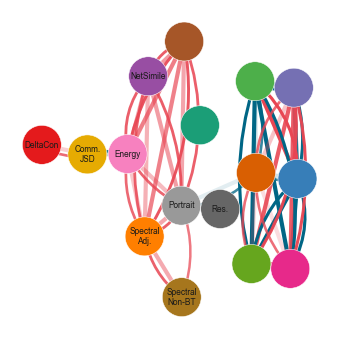

Saved correlation network to /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/05_mst_animal_0/all_metrics_for_05_mst_animal_0.csv
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/05_mst_animal_0/correlation_graph.pdf


In [20]:
from matplotlib.patches import FancyArrowPatch

def draw_bundled_edges(
    G,
    pos,
    ax,
    communities,
    community_centers,
    methods,
    color_pos,
    color_neg,
    base_rad=0.25,
    bundle_strength=0.6,
    width_scale=3.0,
    alpha_min=0.2,
):
    """
    Draw edges bent toward their community center (light edge bundling).

    Parameters
    ----------
    G : nx.Graph
    pos : dict
        Node -> (x, y)
    ax : matplotlib axis
    communities : array-like
        Community index per method (same order as methods)
    community_centers : dict
        community_id -> np.array([x, y])
    methods : list
        Node ordering used when creating communities
    color_pos / color_neg : color
        Edge colors for positive / negative correlations
    base_rad : float
        Base curvature radius
    bundle_strength : float
        How strongly edges bend toward community center (0–1)
    width_scale : float
        Scales edge thickness
    alpha_min : float
        Minimum edge alpha
    """

    normalized_weights_for_alpha = [
        np.abs(G[u][v]["weight"]) for u, v in G.edges()
    ]
    # Normalize weights for alpha
    max_weight = max(normalized_weights_for_alpha) if normalized_weights_for_alpha else 1
    normalized_weights_for_alpha = [w / max_weight for w in normalized_weights_for_alpha]
    alphas = np.array(normalized_weights_for_alpha) * (1 - alpha_min) + alpha_min
    # Map node -> community
    node_to_comm = {m: c for m, c in zip(methods, communities)}

    for i, (u, v) in enumerate(G.edges()):
        weight = G[u][v]["weight"]
        corr = G[u][v]["correlation"]

        # Edge color
        color = color_neg if corr < 0 else color_pos

        # Edge transparency
        
        alpha = alphas[i] # alpha_min + (1 - alpha_min) * weight - 0.01

        # Community center
        cu = node_to_comm[u]
        cv = node_to_comm[v]

        if cu == cv:
            center = community_centers[cu]
        else:
            center = 0.5 * (community_centers[cu] + community_centers[cv])

        # Alternate curvature sign to reduce overlap
        sign = -1 if i % 2 == 0 else 1
        rad = sign * base_rad * (1 + (i % 3) * 0.3)

        # Create curved edge
        edge = FancyArrowPatch(
            posA=pos[u],
            posB=pos[v],
            arrowstyle='-',
            linewidth=width_scale * weight + 0.5,
            color=color,
            alpha=alpha,
            connectionstyle=f"arc3,rad={rad}",
            zorder=1
        )

        ax.add_patch(edge)



"""
Create a network graph where methods are nodes and correlations are edges.
Uses hierarchical clustering to position nodes.
"""


from scipy.cluster.hierarchy import fcluster



selected_methods = [
    "energy", 
    "portrait",
    "spectral_distance_adjacency",
    # "spectral_distance_norm_laplacian", 
    
    # "communicability_corr",
    "communicability_jsd",
    # "network_mutual_information",
    # "dc_network_mutual_information", 
    
    "net_simile", 
    "netrd_non_backtracking_spectral", 
    "resistance", 
    "delta_con", 
    
    # "f1", 
    # "hamming",
    # "frobenius", 
    # "jaccard", 
]

save_folder=save_path
threshold_top_percent=0.3

# Get clustering information
clustered_corr, order, linkage_matrix = cluster_correlation_matrix(corr_matrix)

# Extract communities (adjust t parameter to control number of clusters)
communities = fcluster(linkage_matrix, t=5, # 2, # 1.5, 
                        criterion='distance')

# Create graph
G = nx.Graph()
methods = corr_matrix.columns.tolist()
G.add_nodes_from(methods)



# get threshold over which weights are taken 
all_weights = corr_matrix.values.flatten()
all_weights = all_weights[~np.isnan(all_weights)]
all_weights = np.abs(all_weights)
all_weights = sorted(all_weights, reverse=True)
top_n = int(len(all_weights) * threshold_top_percent) # threshold_top_percent could for example be 10 percent
threshold = all_weights[top_n - 1]

# # Add edges for correlations above threshold
for i, method1 in enumerate(methods):
    for j, method2 in enumerate(methods):
        if i < j:
            corr_value = corr_matrix.loc[method1, method2]
            if not np.isnan(corr_value) and abs(corr_value) >= threshold:
                G.add_edge(method1, method2, weight=abs(corr_value), 
                            correlation=corr_value)
                    



# Create community-informed layout
# First, get positions for each community center
unique_communities = np.unique(communities)
n_communities = len(unique_communities)

# Place community centers in a circle
community_centers = {}
for i, comm in enumerate(unique_communities):
    angle = 2 * np.pi * i / n_communities
    community_centers[comm] = np.array([np.cos(angle), np.sin(angle)]) * 3

# nodes to communities
node_to_community = {method: comm for method, comm in zip(methods, communities)}

np.random.seed(0)  # For reproducibility
# Initialize positions based on community membership
initial_pos = {}
for method, comm in zip(methods, communities):
    # Add small random offset within community
    offset = np.random.randn(2) * 0.3
    initial_pos[method] = community_centers[comm] + offset


def separate_overlapping_nodes(pos, node_radius=0.3, max_iter=100):
    """
    Ensure all nodes are at least 2 * node_radius apart.
    pos: dict of node -> np.array([x, y])
    node_radius: radius of each node
    max_iter: maximum adjustment iterations
    """
    nodes = list(pos.keys())
    positions = pos.copy()
    min_dist = 2 * node_radius  # minimum distance between centers

    for _ in range(max_iter):
        moved = False
        for i, n1 in enumerate(nodes):
            for j, n2 in enumerate(nodes):
                if i >= j:
                    continue
                delta = positions[n2] - positions[n1]
                dist = np.linalg.norm(delta)
                if dist < min_dist and dist > 0:
                    # push nodes apart
                    shift = (min_dist - dist) / 2
                    positions[n1] -= shift * delta / dist
                    positions[n2] += shift * delta / dist
                    moved = True
        if not moved:
            break

    return positions

# def adjust_node_positions(pos, node_sizes, min_distance=0.35, max_iter=50):
#     """
#     Adjust node positions to prevent overlaps.
#     pos: dict of node -> np.array([x, y])
#     node_sizes: dict of node -> size (used to compute min spacing)
#     min_distance: minimum normalized distance between nodes
#     max_iter: maximum number of adjustment iterations
#     """
#     nodes = list(pos.keys())
#     positions = pos.copy()
#     for _ in range(max_iter):
#         moved = False
#         for i, n1 in enumerate(nodes):
#             for j, n2 in enumerate(nodes):
#                 if i >= j:
#                     continue
#                 delta = positions[n2] - positions[n1]
#                 dist = np.linalg.norm(delta)
#                 desired_dist = node_sizes[n1] * 2 # min_distance + (node_sizes[n1]**0.5 + node_sizes[n2]**0.5) / 1000
#                 if dist < desired_dist and dist > 0:
#                     # push nodes apart proportionally
#                     shift = (desired_dist - dist) / 2
#                     positions[n1] -= shift * delta / dist
#                     positions[n2] += shift * delta / dist
#                     moved = True
#         if not moved:
#             break
#     return positions

# Adjust positions
pos = nx.kamada_kawai_layout(G,
                             pos=initial_pos, 
                             scale=4) # 1.5
# pos = adjust_node_positions(pos, node_size_dict, min_distance=0.01) # .5) # 0.01)
pos = separate_overlapping_nodes(pos, node_radius=0.5) # 0.19) # node_sizes[0]//2)


# Create figure
fig, ax = plt.subplots(figsize=viz.cm_to_inch((6,6)), dpi=150)

# Draw nodes (keep original colors)
node_colors = [metric_colors[node] for node in G.nodes()]
node_sizes = [350 for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                        node_size=node_sizes, alpha=1, ax=ax, linewidths=0.25, edgecolors='white')

# Draw edges
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
# normalize weights
weights = (weights - min(weights)) / (max(weights) - min(weights))

correlations = [G[u][v]['correlation'] for u, v in edges]
edge_widths = [w * 4 for w in weights]

# use the extreme values of this: default_cmaps["db_bw_lr"]
edge_colors = [color_neg1 if c < 0 else color_pos1 for c in correlations]

nx.draw_networkx_edges(G, pos, 
                       width=2, # edge_widths, 
                       alpha=weights, # 0.6,
                       edge_color=edge_colors, 
                       arrows=True, 
                       connectionstyle="arc", 
                       ax=ax)


label_shorthands = {
    "energy": "Energy", 
    "portrait": "Portrait",
    "spectral_distance_adjacency": "Spectral\nAdj.",
    "communicability_jsd": "Comm.\nJSD",
    "net_simile": "NetSimile", 
    "netrd_non_backtracking_spectral": "Spectral\nNon-BT", 
    "resistance": "Res.", 
    "delta_con": "DeltaCon", 
}

# Draw labels
# labels = {node: method_names[node].replace(' ', '\n').replace('-', '-\n') 
#           for node in G.nodes() if node in selected_methods}
labels = {node: label_shorthands[node]
            for node in G.nodes() if node in selected_methods}
# print("labels:", selected_methods)

nx.draw_networkx_labels(G, pos, labels, font_size=4, ax=ax) # 3

draw_bundled_edges(
    G,
    pos,
    ax,
    communities=communities,
    community_centers=community_centers,
    methods=methods,
    color_pos=color_pos1,
    color_neg=color_neg1,
    base_rad=0.15,
    bundle_strength=1, # 0.1,
    width_scale=1.0,
    alpha_min=0.1, # .25,
)

ax.axis('off')
plt.tight_layout()
plt.savefig(save_folder.parent / "correlation_graph.pdf")
plt.show()
print(f"Saved correlation network to {save_path}")
print(save_folder.parent / "correlation_graph.pdf")

In [21]:
# import numpy as np
# import matplotlib.pyplot as plt
# import networkx as nx
# from netgraph import Graph
# from scipy.cluster.hierarchy import fcluster

# # Parameters
# threshold = 0.5
# color_pos1 = "#b2182b"   # positive correlations (red)
# color_neg1 = "#2166ac"   # negative correlations (blue)

# label_shorthands = {
#     "energy": "Energy", 
#     "portrait": "Portrait",
#     "spectral_distance_adjacency": "Spectral\nAdj.",
#     "communicability_jsd": "Comm.\nJSD",
#     "net_simile": "NetSimile", 
#     "netrd_non_backtracking_spectral": "Spectral\nNon-BT", 
#     "resistance": "Res.", 
#     "delta_con": "DeltaCon", 
# }

# # Build graph
# G = nx.Graph()
# methods = corr_matrix.columns.tolist()
# G.add_nodes_from(methods)

# for i, m1 in enumerate(methods):
#     for j, m2 in enumerate(methods):
#         if i < j:
#             corr = corr_matrix.loc[m1, m2]
#             if not np.isnan(corr) and abs(corr) >= threshold:
#                 G.add_edge(
#                     m1, m2,
#                     weight=abs(corr),
#                     correlation=corr
#                 )
                

# # Community detection (from clustering)
# clustered_corr, order, linkage_matrix = cluster_correlation_matrix(corr_matrix)

# communities = fcluster(
#     linkage_matrix,
#     t=5,
#     criterion="distance"
# )

# node_to_community = {
#     node: int(comm)
#     for node, comm in zip(methods, communities)
# }


# # Node colors
# node_color = {
#     node: metric_colors[node]
#     for node in G.nodes()
# }


# # Edge colors & widths
# edge_color = {}
# edge_width = {}

# for u, v, data in G.edges(data=True):
#     corr = data["correlation"]
#     w = data["weight"]

#     edge_color[(u, v)] = color_pos1 if corr > 0 else color_neg1
#     edge_width[(u, v)] = 0.1 + 2.5 * w   # scale nicely

# # Labels
# node_labels = {
#     node: label_shorthands[node]
#     for node in G.nodes()
#     if node in label_shorthands
# }


# # Plot
# fig, ax = plt.subplots(figsize=viz.cm_to_inch((6, 6)), dpi=150)

# Graph(
#     G,
#     ax=ax,

#     # ---- nodes ----
#     node_layout="spring", # "spring", # "kamada_kawai", # "spring", # "community",
#     node_layout_kwargs=dict(
#         k=2,
#         pos=pos,
#         # node_to_community=node_to_community,
#         # community_layout="circular",
#     ),
#     node_color=node_color,
#     node_size=8, # 10,
#     node_edge_width=0.5, # 0.8,
#     node_edge_color="white",

#     # ---- edges ----
#     edge_layout="bundled",
#     edge_color=edge_color,
#     edge_width=edge_width,
#     edge_alpha=0.6,

#     # ---- labels ----
#     node_labels=node_labels,
#     node_label_fontsize=20,
# )

# ax.axis("off")
# plt.tight_layout()
# plt.savefig(save_folder.parent / "correlation_graph_bundled.pdf")
# plt.show()

# print("Saved to:", save_folder.parent / "correlation_graph_bundled.pdf")


In [22]:
# # Use the edge_layout option to bundle the edges together

# from netgraph import Graph


# fig, ax = plt.subplots()
# Graph(G, 
#       node_edge_width=1,     
#       edge_width=1,        
#       edge_alpha=0.5,       
#       node_layout='community', node_layout_kwargs=dict(node_to_community=node_to_community),
#       edge_layout='bundled', # this is where bundling is made possible
#       ax=ax,
# )
# plt.show()

In [23]:
all_dist_measures = [m for m in all_dist_measures]
all_dist_measures = all_dist_measures[::-1]

# Color id 
color_ids = {
    "energy": 1, 
    "portrait": 3, 
    "spectral_distance_adjacency": 13,
    # "spectral_distance_norm_laplacian": 4,

    # "communicability_corr": 5,
    # "communicability_jsd": 6,
    # "network_mutual_information": 7,
    # "dc_network_mutual_information": 8,

    "net_simile": 4,
    "netrd_non_backtracking_spectral": 12,
    "resistance": 8,
    "delta_con": 14,

    # "f1": 13,
    # "hamming": 14,
    "frobenius": 7,
    # "jaccard": 16,
}



communicability_corr
dc_network_mutual_information
network_mutual_information
f1
jaccard
communicability_jsd
netrd_non_backtracking_spectral
resistance
delta_con
hamming
frobenius
net_simile
spectral_distance_adjacency
spectral_distance_norm_laplacian
energy
portrait
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/05_mst_animal_0/figures_manuscript_apdx/sixteen_subplots_colored.pdf


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_93857/4248448849.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


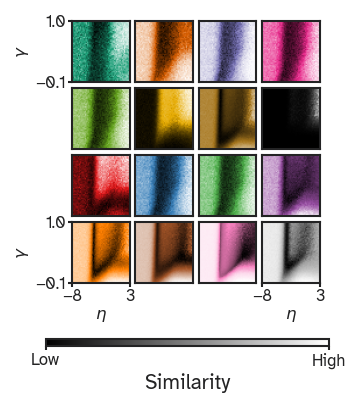

In [24]:
n_methods = len(all_dist_measures)
n_cols = 4
n_rows = int(np.ceil(n_methods / n_cols))

image_size_in_cm = 6
fontsize = 8
# Calculate height to maintain roughly square subplots
height = image_size_in_cm * (n_rows / n_cols) 

fig, axes = plt.subplots(n_rows, n_cols, 
                            figsize=viz.cm_to_inch((image_size_in_cm, height)), # 18, height)), 
                            dpi=150,
                            squeeze=True,
                            # sharex=True, 
                            # sharey=True
                            )

axes = axes.flatten()

for idx, mode in enumerate(all_dist_measures):
    ax = axes[idx]

    
    cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
        f'custom_cmap_{mode}', 
        [
            "black",
            metric_colors[mode], 
            "white", 
            # bone_white

        #  
        #  color_neg1,
        #  halfblack, 
        #  bone_white, 
         ]
    )
    # cmap = default_cmaps["metric_purple_beige"]

    scatter = ax.imshow(matrices_of_metrics[mode], 
                        cmap=cmap, 
                       aspect='auto',
                    #    origin='lower',
                       extent=[
                           df["eta"].min(), df["eta"].max(),
                           df["gamma"].min(), df["gamma"].max()
                       ])
    
    # ax.set_xlim(-8, 3)
    # ax.set_ylim(-0.1, 1)
    
    # Set ticks
    if (idx % n_cols == 0 and idx // n_cols == n_rows -1): 
        ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
        ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
        ax.set_xlabel(r"$\eta$", fontsize=fontsize)
        ax.set_ylabel(r"$\gamma$", fontsize=fontsize)
    elif idx == 0: 
        ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
        ax.set_xticks([]) 
        ax.set_ylabel(r"$\gamma$", fontsize=fontsize)
    elif idx == len(all_dist_measures) -1: 
        ax.set_yticks([])
        ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
        ax.set_xlabel(r"$\eta$", fontsize=fontsize)
    else: 
        ax.set_yticks([])
        ax.set_xticks([])
    # Add title for each subplot
    print(mode)
    title = method_names[mode] # f"{metric_col[0].split('subject')[0].replace('_', ' ').capitalize()}"
    # ax.set_title(title, fontsize=8)
    
    # # Add colorbar for each subplot
    # cbar = plt.colorbar(scatter, ax=ax)
    # cbar.ax.tick_params(labelsize=6)
    
    # # Only add labels to edge subplots
    # if idx % n_cols == 0:  # Left column
    #     ax.set_ylabel(r"$\gamma$")
    # if idx >= n_methods - n_cols:  # Bottom row
    #     ax.set_xlabel(r"$\eta$")

# fig.supxlabel(r"$\eta$")
# fig.supylabel(r"$\gamma$")

# Hide unused subplots
for idx in range(n_methods, len(axes)):
    axes[idx].axis('off')


# Get min and max location of the corners of the subplots
x_min = np.min([ax.get_position().x0 for ax in axes]) + 0.025
x_max = np.max([ax.get_position().x1 for ax in axes]) + 2 * 0.025
y_min = np.min([ax.get_position().y0 for ax in axes])
y_max = np.max([ax.get_position().y1 for ax in axes])

# Add one shared colorbar below all subplots
cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
        f'custom_cmap_{mode}', 
        [
            "black",
            # metric_colors[mode], 
            "white", 
            # bone_white

        #  
        #  color_neg1,
        #  halfblack, 
        #  bone_white, 
         ])
values_for_cbar = np.linspace(0, 1, 256)
norm = plt.Normalize(vmin=0, vmax=10)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
# cbar_ax = fig.add_axes([0.25, 0.0, 0.5, 0.01])  # [left, bottom, width, height]
cbar_ax = fig.add_axes([x_min, 0, x_max - x_min, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Similarity") #  (Higher for darker colors)") # Darker: More similar. Lighter: Less similar")
cbar.ax.tick_params(labelsize=8)
cbar.ax.set_xticks([0, 10], labels=['Low', 'High'])
plt.tight_layout()

plt.subplots_adjust(wspace=0.1, hspace=0.1)  # Reduce these values for tighter spacing

plt.savefig(output_path / "sixteen_subplots_colored.pdf", bbox_inches='tight')
print(output_path / "sixteen_subplots_colored.pdf")

plt.show()

In [25]:
    # n_methods = len(all_dist_measures)
    # n_cols = 4
    # n_rows = int(np.ceil(n_methods / n_cols))

    # image_size_in_cm = 6
    # fontsize = 8
    # # Calculate height to maintain roughly square subplots
    # height = image_size_in_cm * (n_rows / n_cols) 

    # fig, axes = plt.subplots(n_rows, n_cols, 
    #                             figsize=viz.cm_to_inch((image_size_in_cm, height)), # 18, height)), 
    #                             dpi=150,
    #                             squeeze=True,
    #                             # sharex=True, 
    #                             # sharey=True
    #                             )

    # axes = axes.flatten()

    # for idx, mode in enumerate(all_dist_measures):
    #     ax = axes[idx]

        
    #     cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
    #         f'custom_cmap_{mode}', 
    #         [
    #             "black",
    #             metric_colors[mode], 
    #             "white", 
    #             # bone_white

    #         #  
    #         #  color_neg1,
    #         #  halfblack, 
    #         #  bone_white, 
    #         ]
    #     )
    #     # cmap = default_cmaps["metric_purple_beige"]

    #     scatter = ax.imshow(matrices_of_metrics[mode], 
    #                         cmap=cmap, 
    #                     aspect='auto',
    #                     #    origin='lower',
    #                     extent=[
    #                         df["eta"].min(), df["eta"].max(),
    #                         df["gamma"].min(), df["gamma"].max()
    #                     ])
        
    #     # ax.set_xlim(-8, 3)
    #     # ax.set_ylim(-0.1, 1)
        
    #     # Set ticks
    #     if (idx % n_cols == 0 and idx // n_cols == n_rows -1): 
    #         ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
    #         ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
    #         ax.set_xlabel(r"$\eta$", fontsize=fontsize)
    #         ax.set_ylabel(r"$\gamma$", fontsize=fontsize)
    #     elif idx == 0: 
    #         ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
    #         ax.set_xticks([]) 
    #         ax.set_ylabel(r"$\gamma$", fontsize=fontsize)
    #     elif idx == len(all_dist_measures) -1: 
    #         ax.set_yticks([])
    #         ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
    #         ax.set_xlabel(r"$\eta$", fontsize=fontsize)
    #     else: 
    #         ax.set_yticks([])
    #         ax.set_xticks([])
    #     # Add title for each subplot
    #     print(mode)
    #     title = method_names[mode] # f"{metric_col[0].split('subject')[0].replace('_', ' ').capitalize()}"
    #     # ax.set_title(title, fontsize=8)
        
    #     # # Add colorbar for each subplot
    #     # cbar = plt.colorbar(scatter, ax=ax)
    #     # cbar.ax.tick_params(labelsize=6)
        
    #     # # Only add labels to edge subplots
    #     # if idx % n_cols == 0:  # Left column
    #     #     ax.set_ylabel(r"$\gamma$")
    #     # if idx >= n_methods - n_cols:  # Bottom row
    #     #     ax.set_xlabel(r"$\eta$")

    # # fig.supxlabel(r"$\eta$")
    # # fig.supylabel(r"$\gamma$")

    # # Hide unused subplots
    # # for idx in range(n_methods, len(axes)):
    # #     axes[idx].axis('off')


    # # # Get min and max location of the corners of the subplots
    # # x_min = np.min([ax.get_position().x0 for ax in axes]) + 0.025
    # # x_max = np.max([ax.get_position().x1 for ax in axes]) + 2 * 0.025
    # # y_min = np.min([ax.get_position().y0 for ax in axes])
    # # y_max = np.max([ax.get_position().y1 for ax in axes])

    # # Add one shared colorbar below all subplots
    # # cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
    # #         f'custom_cmap_{mode}', 
    # #         [
    # #             "black",
    # #             # metric_colors[mode], 
    # #             "white", 
    # #             # bone_white

    # #         #  
    # #         #  color_neg1,
    # #         #  halfblack, 
    # #         #  bone_white, 
    # #          ])
    # # values_for_cbar = np.linspace(0, 1, 256)
    # # norm = plt.Normalize(vmin=0, vmax=10)
    # # sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    # # sm.set_array([])
    # # # cbar_ax = fig.add_axes([0.25, 0.0, 0.5, 0.01])  # [left, bottom, width, height]
    # # cbar_ax = fig.add_axes([x_min, 0, x_max - x_min, 0.02])  # [left, bottom, width, height]
    # # cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    # # cbar.set_label("Similarity") #  (Higher for darker colors)") # Darker: More similar. Lighter: Less similar")
    # # cbar.ax.tick_params(labelsize=8)
    # # cbar.ax.set_xticks([0, 10], labels=['Low', 'High'])
    # # plt.tight_layout()

    # plt.subplots_adjust(wspace=0.1, hspace=0.1)  # Reduce these values for tighter spacing

    # plt.savefig(output_path / "sixteen_subplots_colored_only_landscapes.pdf", bbox_inches='tight')
    # print(output_path / "sixteen_subplots_colored_only_landscapes.pdf")

    # plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/05_mst_animal_0/figures_manuscript_apdx/cbar_pearson_corr.pdf


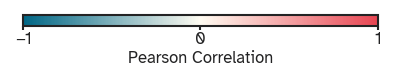

In [26]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

# ----------------------------
# FIGURE & GRIDSPEC
# ----------------------------
fig = plt.figure(
    figsize=viz.cm_to_inch((6, 6)),
    dpi=150
)

# gs = GridSpec(
#     2, 2,
#     width_ratios=[0.05, 1],
#     height_ratios=[1, 0.08],
#     wspace=0.05,
#     hspace=0.15
# )

# # ----------------------------
# # HEATMAP
# # ----------------------------
# ax_heatmap = fig.add_subplot(gs[0, 1])

# sns.heatmap(
#     clustered_corr,
#     cmap=default_cmaps["db_bw_lr"],
#     square=True,
#     cbar=False,
#     ax=ax_heatmap
# )

# ax_heatmap.set_xticks([])
# ax_heatmap.set_yticks([])
# ax_heatmap.invert_xaxis()
# ax_heatmap.invert_yaxis()

# ax_heatmap.set_xlabel("")
# ax_heatmap.set_ylabel("")

# for spine in ax_heatmap.spines.values():
#     spine.set_visible(True)
#     # spine.set_linewidth(0.5)

# # ----------------------------
# # LEFT METHOD COLOR STRIP
# # ----------------------------
# ax_strip = fig.add_subplot(gs[0, 0])

# colors = [metric_colors[m] for m in all_dist_measures]
# strip = np.arange(len(colors)).reshape(-1, 1)

# ax_strip.imshow(
#     strip,
#     aspect="auto",
#     cmap=plt.cm.colors.ListedColormap(colors)
# )

# ax_strip.set_xticks([])
# ax_strip.set_yticks([])
# for spine in ax_strip.spines.values():
#     spine.set_visible(True)
#     # spine.set_linewidth(0.5)



# Pearson colorbar 
cbar_ax = fig.add_axes([0, 0, 1, 0.03])  # [left, bottom, width, height]

sm = plt.cm.ScalarMappable(
    cmap=default_cmaps["db_bw_lr"],
    norm=plt.Normalize(-1, 1)
)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Pearson Correlation", fontsize=fontsize)
cbar.set_ticks([-1, 0, 1])
cbar.ax.tick_params(labelsize=fontsize)

# Save 
plt.savefig(output_path / "cbar_pearson_corr.pdf", bbox_inches="tight")
print(output_path / "cbar_pearson_corr.pdf")
plt.show()


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/05_mst_animal_0/figures_manuscript_apdx/cbar_similarity.pdf


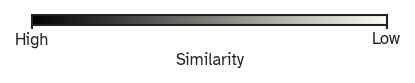

In [27]:
fig = plt.figure(
    figsize=viz.cm_to_inch((6, 6)),
    dpi=150
)

# Pearson colorbar 
cbar_ax = fig.add_axes([0, 0, 1, 0.03])  # [left, bottom, width, height]

sm = plt.cm.ScalarMappable(
    cmap=black_white_map.reversed(), # default_cmaps["db_bw_lr"],
    norm=plt.Normalize(-1, 1)
)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Similarity", fontsize=fontsize)
cbar.set_ticks([-1, 1])
cbar.ax.set_xticklabels(['High', 'Low'])

cbar.ax.tick_params(labelsize=fontsize)

# Save 
plt.savefig(output_path / "cbar_similarity.pdf", bbox_inches="tight")
print(output_path / "cbar_similarity.pdf")
plt.show()


In [28]:
# fig = plt.figure(
#     figsize=viz.cm_to_inch((6, 6)),
#     dpi=150
# )

# # Pearson colorbar 
# cbar_ax = fig.add_axes([0, 0, 1, 0.03])  # [left, bottom, width, height]

# sm = plt.cm.ScalarMappable(
#     cmap=default_cmaps["db_bw_lr"],
#     norm=plt.Normalize(-1, 1)
# )
# sm.set_array([])

# cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
# cbar.set_label("Pearson Correlation", fontsize=fontsize)
# cbar.set_ticks([-1, 0, 1])
# cbar.ax.tick_params(labelsize=fontsize)

# # Save 
# plt.savefig(output_path / "cbar_pearson_corr.pdf", bbox_inches="tight")
# print(output_path / "cbar_pearson_corr.pdf")
# plt.show()


In [29]:
# all_dist_measures = all_dist_measures
        
# n_methods = len(all_dist_measures[::-1])
# n_cols = 4
# n_rows = int(np.ceil(n_methods / n_cols))

# image_size_in_cm = 6
# fontsize = 8
# height = image_size_in_cm * (n_rows / n_cols) 

# fig, axes = plt.subplots(n_rows, n_cols, 
#                             figsize=viz.cm_to_inch((image_size_in_cm, height)),
#                             dpi=150,
#                             squeeze=True,
#                             constrained_layout=False
#                             )

# axes = axes.flatten()

# for idx, mode in enumerate(all_dist_measures[::-1]):
#     ax = axes[idx]
    
#     cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
#         f'custom_cmap_{mode}', 
#         [
#             "black",
#             metric_colors[mode], 
#             "white", 
#          ]
#     )

#     scatter = ax.imshow(matrices_of_metrics[mode], 
#                         cmap=cmap, 
#                        aspect='auto',
#                        extent=[
#                            df["eta"].min(), df["eta"].max(),
#                            df["gamma"].min(), df["gamma"].max()
#                        ])
    
#     # Minimum points: Scatter plot around the 100 lowest values
#     flat_indices = np.argsort(matrices_of_metrics[mode].flatten())[:100]
#     row_indices, col_indices = np.unravel_index(flat_indices, matrices_of_metrics[mode].shape)

#     # Convert matrix indices to coordinate space
#     eta_coords = np.linspace(df["eta"].min(), df["eta"].max(), matrices_of_metrics[mode].shape[1])
#     gamma_coords = np.linspace(df["gamma"].min(), df["gamma"].max(), matrices_of_metrics[mode].shape[0])

#     # Flip row indices to match imshow's top-to-bottom orientation
#     row_indices = matrices_of_metrics[mode].shape[0] - 1 - row_indices

#     ax.scatter(eta_coords[col_indices], gamma_coords[row_indices], 
#             color=metric_colors[mode], 
#             edgecolor='white', 
#             linewidth=0.5,
#             s=3,
#             label='Lowest 100 values')
    
#     # Set ticks
#     if (idx % n_cols == 0 and idx // n_cols == n_rows -1): 
#         ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
#         ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
#         ax.set_xlabel(r"$\eta$", fontsize=fontsize)
#         ax.set_ylabel(r"$\gamma$", fontsize=fontsize)
#     elif idx == 0: 
#         ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
#         ax.set_xticks([]) 
#         ax.set_ylabel(r"$\gamma$", fontsize=fontsize)
#     elif idx == len(all_dist_measures[::-1]) -1: 
#         ax.set_yticks([])
#         ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
#         ax.set_xlabel(r"$\eta$", fontsize=fontsize)
#     else: 
#         ax.set_yticks([])
#         ax.set_xticks([])

#     ax.vlines(x=0, ymin=df["gamma"].min(), ymax=df["gamma"].max(), 
#               colors='black', linestyles='dashed', linewidth=0.6) # 4)

# # Hide unused subplots
# for idx in range(n_methods, len(axes)):
#     axes[idx].axis('off')

# # Adjust spacing manually to leave room for colorbar at bottom
# plt.subplots_adjust(left=0.1, right=0.95, bottom=0.12, top=0.98, wspace=0.1, hspace=0.1)

# # Get positions AFTER subplots_adjust
# x_min = np.min([ax.get_position().x0 for ax in axes[:n_methods]])
# x_max = np.max([ax.get_position().x1 for ax in axes[:n_methods]])

# # Add one shared colorbar below all subplots
# cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
#         f'custom_cmap_colorbar', 
#         ["black", "white"])
# norm = plt.Normalize(vmin=0, vmax=10)
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])

# # Position colorbar with space for labels
# cbar_ax = fig.add_axes([x_min, 
#                         -0.05, # 0.03, 
#                         x_max - x_min, 0.02])
# cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
# cbar.set_label("Similarity")
# cbar.ax.tick_params(labelsize=8)
# cbar.ax.set_xticks([0, 10], labels=['Low', 'High'])

# # Save FIRST, then show
# plt.savefig(output_path / "sixteen_subplots_colored_with_100_mins.pdf", bbox_inches='tight', pad_inches=0.1)
# print(output_path / "sixteen_subplots_colored_with_100_mins.pdf")
# plt.show()

In [30]:
# all_dist_measures = all_dist_measures
        
# n_methods = len(all_dist_measures[::-1])
# n_cols = 4
# n_rows = int(np.ceil(n_methods / n_cols))

# image_size_in_cm = 6
# fontsize = 8
# height = image_size_in_cm * (n_rows / n_cols) 

# fig, axes = plt.subplots(n_rows, n_cols, 
#                             figsize=viz.cm_to_inch((image_size_in_cm, height)), # 18, height)), 
#                             dpi=150,
#                             squeeze=True,
#                             # sharex=True, 
#                             # sharey=True
#                             )


# axes = axes.flatten()

# for idx, mode in enumerate(all_dist_measures[::-1]):
#     ax = axes[idx]

    
#     cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
#         f'custom_cmap_{mode}', 
#         [
#             "black",
#             metric_colors[mode], 
#             "white", 
#          ]
#     )
#     # cmap = default_cmaps["metric_purple_beige"]

#     scatter = ax.imshow(matrices_of_metrics[mode], 
#                         cmap=cmap, 
#                        aspect='auto',
#                     #    origin='lower',
#                        extent=[
#                            df["eta"].min(), df["eta"].max(),
#                            df["gamma"].min(), df["gamma"].max()
#                        ])
    
#     # ax.set_xlim(-8, 3)
#     # ax.set_ylim(-0.1, 1)
    
#     # Minimum points: Scatter plot around the 100 lowest values
#     flat_indices = np.argsort(matrices_of_metrics[mode].flatten())[:100]
#     row_indices, col_indices = np.unravel_index(flat_indices, matrices_of_metrics[mode].shape)

#     # Convert matrix indices to coordinate space
#     eta_coords = np.linspace(df["eta"].min(), df["eta"].max(), matrices_of_metrics[mode].shape[1])
#     gamma_coords = np.linspace(df["gamma"].min(), df["gamma"].max(), matrices_of_metrics[mode].shape[0])

#     # Flip row indices to match imshow's top-to-bottom orientation
#     row_indices = matrices_of_metrics[mode].shape[0] - 1 - row_indices

#     ax.scatter(eta_coords[col_indices], gamma_coords[row_indices], 
#             color=metric_colors[mode], 
#             edgecolor='white', 
#             linewidth=0.5,
#             s=3,
#             label='Lowest 100 values')
    
    
#     # Set ticks
#     if (idx % n_cols == 0 and idx // n_cols == n_rows -1): 
#         ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
#         ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
#         ax.set_xlabel(r"$\eta$", fontsize=fontsize)
#         ax.set_ylabel(r"$\gamma$", fontsize=fontsize)
#     elif idx == 0: 
#         ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
#         ax.set_xticks([]) 
#         ax.set_ylabel(r"$\gamma$", fontsize=fontsize)
#     elif idx == len(all_dist_measures) -1: 
#         ax.set_yticks([])
#         ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
#         ax.set_xlabel(r"$\eta$", fontsize=fontsize)
#     else: 
#         ax.set_yticks([])
#         ax.set_xticks([])
#     # Add title for each subplot
#     print(mode)
#     title = method_names[mode] # f"{metric_col[0].split('subject')[0].replace('_', ' ').capitalize()}"
#     # ax.set_title(title, fontsize=8)
    
#     # # Add colorbar for each subplot
#     # cbar = plt.colorbar(scatter, ax=ax)
#     # cbar.ax.tick_params(labelsize=6)
    
#     # # Only add labels to edge subplots
#     # if idx % n_cols == 0:  # Left column
#     #     ax.set_ylabel(r"$\gamma$")
#     # if idx >= n_methods - n_cols:  # Bottom row
#     #     ax.set_xlabel(r"$\eta$")

#     ax.vlines(x=0, ymin=df["gamma"].min(), ymax=df["gamma"].max(), colors='black', linestyles='dashed', linewidth=0.4)

# # fig.supxlabel(r"$\eta$")
# # fig.supylabel(r"$\gamma$")

# # Hide unused subplots
# for idx in range(n_methods, len(axes)):
#     axes[idx].axis('off')


# # Get min and max location of the corners of the subplots
# x_min = np.min([ax.get_position().x0 for ax in axes]) + 0.025
# x_max = np.max([ax.get_position().x1 for ax in axes]) + 2 * 0.025
# y_min = np.min([ax.get_position().y0 for ax in axes])
# y_max = np.max([ax.get_position().y1 for ax in axes])

# # Add one shared colorbar below all subplots
# cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
#         f'custom_cmap_{mode}', 
#         [
#             "black",
#             # metric_colors[mode], 
#             "white", 
#             # bone_white

#         #  
#         #  color_neg1,
#         #  halfblack, 
#         #  bone_white, 
#          ])
# values_for_cbar = np.linspace(0, 1, 256)
# norm = plt.Normalize(vmin=0, vmax=10)
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])
# # cbar_ax = fig.add_axes([0.25, 0.0, 0.5, 0.01])  # [left, bottom, width, height]
# cbar_ax = fig.add_axes([x_min, 0, x_max - x_min, 0.02])  # [left, bottom, width, height]
# cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
# cbar.set_label("Similarity") #  (Higher for darker colors)") # Darker: More similar. Lighter: Less similar")
# cbar.ax.tick_params(labelsize=8)
# cbar.ax.set_xticks([0, 10], labels=['Low', 'High'])
# plt.tight_layout()

# plt.subplots_adjust(wspace=0.1, hspace=0.1)  # Reduce these values for tighter spacing

# plt.savefig(output_path / "sixteen_subplots_colored.pdf")
# print(output_path / "sixteen_subplots_colored.pdf")

# plt.show()




/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/05_mst_animal_0/figures_manuscript_apdx/sixteen_subplots_colored_with_100_mins.pdf


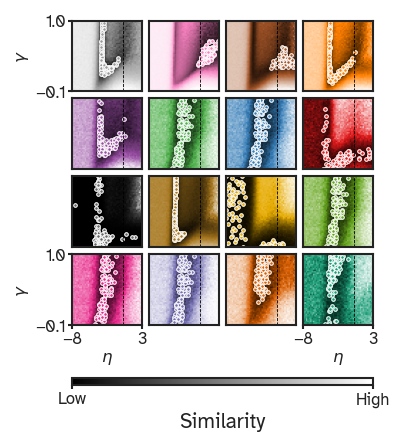

In [31]:
all_dist_measures = all_dist_measures
        
n_methods = len(all_dist_measures[::-1])
n_cols = 4
n_rows = int(np.ceil(n_methods / n_cols))

image_size_in_cm = 6
fontsize = 8
height = image_size_in_cm * (n_rows / n_cols) 

fig, axes = plt.subplots(n_rows, n_cols, 
                            figsize=viz.cm_to_inch((image_size_in_cm, height)),
                            dpi=150,
                            squeeze=True,
                            constrained_layout=False
                            )

axes = axes.flatten()

for idx, mode in enumerate(all_dist_measures[::-1]):
    ax = axes[idx]
    
    cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
        f'custom_cmap_{mode}', 
        [
            "black",
            metric_colors[mode], 
            "white", 
         ]
    )

    scatter = ax.imshow(matrices_of_metrics[mode], 
                        cmap=cmap, 
                       aspect='auto',
                       extent=[
                           df["eta"].min(), df["eta"].max(),
                           df["gamma"].min(), df["gamma"].max()
                       ])
    
    # Minimum points: Scatter plot around the 100 lowest values
    NUMBER_BEST_NETWORKS = 100
    flat_indices = np.argsort(matrices_of_metrics[mode].flatten())[:NUMBER_BEST_NETWORKS]
    row_indices, col_indices = np.unravel_index(flat_indices, matrices_of_metrics[mode].shape)

    # Convert matrix indices to coordinate space
    eta_coords = np.linspace(df["eta"].min(), df["eta"].max(), matrices_of_metrics[mode].shape[1])
    gamma_coords = np.linspace(df["gamma"].min(), df["gamma"].max(), matrices_of_metrics[mode].shape[0])

    # Flip row indices to match imshow's top-to-bottom orientation
    row_indices = matrices_of_metrics[mode].shape[0] - 1 - row_indices

    ax.scatter(eta_coords[col_indices], gamma_coords[row_indices], 
            color=metric_colors[mode], 
            edgecolor='white', 
            linewidth=0.5,
            s=3,
            label='Lowest 100 values')
    
    # Set ticks
    if (idx % n_cols == 0 and idx // n_cols == n_rows -1): 
        ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
        ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
        ax.set_xlabel(r"$\eta$", fontsize=fontsize)
        ax.set_ylabel(r"$\gamma$", fontsize=fontsize)
    elif idx == 0: 
        ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
        ax.set_xticks([]) 
        ax.set_ylabel(r"$\gamma$", fontsize=fontsize)
    elif idx == len(all_dist_measures[::-1]) -1: 
        ax.set_yticks([])
        ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
        ax.set_xlabel(r"$\eta$", fontsize=fontsize)
    else: 
        ax.set_yticks([])
        ax.set_xticks([])

    ax.vlines(x=0, ymin=df["gamma"].min(), ymax=df["gamma"].max(), 
              colors='black', linestyles='dashed', linewidth=0.4)

# Hide unused subplots
for idx in range(n_methods, len(axes)):
    axes[idx].axis('off')

# Adjust spacing manually to leave room for colorbar at bottom
plt.subplots_adjust(left=0.1, right=0.95, bottom=0.12, top=0.98, wspace=0.1, hspace=0.1)

# Get positions AFTER subplots_adjust
x_min = np.min([ax.get_position().x0 for ax in axes[:n_methods]])
x_max = np.max([ax.get_position().x1 for ax in axes[:n_methods]])

# Add one shared colorbar below all subplots
cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
        f'custom_cmap_colorbar', 
        ["black", "white"])
norm = plt.Normalize(vmin=0, vmax=10)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Position colorbar with space for labels
cbar_ax = fig.add_axes([x_min, 
                        -0.05, # 0.03, 
                        x_max - x_min, 0.02])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Similarity")
cbar.ax.tick_params(labelsize=8)
cbar.ax.set_xticks([0, 10], labels=['Low', 'High'])

# Save FIRST, then show
plt.savefig(output_path / "sixteen_subplots_colored_with_100_mins.pdf", bbox_inches='tight', pad_inches=0.1)
print(output_path / "sixteen_subplots_colored_with_100_mins.pdf")
plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/05_mst_animal_0/figures_manuscript_apdx/sixteen_subplots_colored_with_100_mins_only_landscapes.pdf


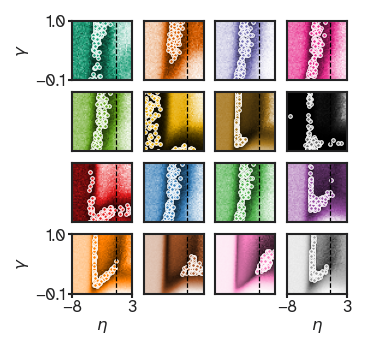

In [32]:
all_dist_measures = all_dist_measures
        
n_methods = len(all_dist_measures)
n_cols = 4
n_rows = int(np.ceil(n_methods / n_cols))

image_size_in_cm = 6
fontsize = 8
height = image_size_in_cm * (n_rows / n_cols) 

fig, axes = plt.subplots(n_rows, n_cols, 
                            figsize=viz.cm_to_inch((image_size_in_cm, height)),
                            dpi=150,
                            squeeze=True,
                            constrained_layout=False
                            )

axes = axes.flatten()

for idx, mode in enumerate(all_dist_measures):
    ax = axes[idx]
    
    cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
        f'custom_cmap_{mode}', 
        [
            "black",
            metric_colors[mode], 
            "white", 
         ]
    )

    scatter = ax.imshow(matrices_of_metrics[mode], 
                        cmap=cmap, 
                       aspect='auto',
                       extent=[
                           df["eta"].min(), df["eta"].max(),
                           df["gamma"].min(), df["gamma"].max()
                       ])
    
    # Minimum points: Scatter plot around the 100 lowest values
    flat_indices = np.argsort(matrices_of_metrics[mode].flatten())[:100]
    row_indices, col_indices = np.unravel_index(flat_indices, matrices_of_metrics[mode].shape)

    # Convert matrix indices to coordinate space
    eta_coords = np.linspace(df["eta"].min(), df["eta"].max(), matrices_of_metrics[mode].shape[1])
    gamma_coords = np.linspace(df["gamma"].min(), df["gamma"].max(), matrices_of_metrics[mode].shape[0])

    # Flip row indices to match imshow's top-to-bottom orientation
    row_indices = matrices_of_metrics[mode].shape[0] - 1 - row_indices

    ax.scatter(eta_coords[col_indices], gamma_coords[row_indices], 
            color=metric_colors[mode], 
            edgecolor='white', 
            linewidth=0.5,
            s=3,
            label='Lowest 100 values')
    
    # Set ticks
    if (idx % n_cols == 0 and idx // n_cols == n_rows -1): 
        ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
        ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
        ax.set_xlabel(r"$\eta$", fontsize=fontsize)
        ax.set_ylabel(r"$\gamma$", fontsize=fontsize)
    elif idx == 0: 
        ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
        ax.set_xticks([]) 
        ax.set_ylabel(r"$\gamma$", fontsize=fontsize)
    elif idx == len(all_dist_measures[::-1]) -1: 
        ax.set_yticks([])
        ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
        ax.set_xlabel(r"$\eta$", fontsize=fontsize)
    else: 
        ax.set_yticks([])
        ax.set_xticks([])

    ax.vlines(x=0, ymin=df["gamma"].min(), ymax=df["gamma"].max(), 
              colors='black', linestyles='dashed', linewidth=0.6) # 4)

# # Hide unused subplots
# for idx in range(n_methods, len(axes)):
#     axes[idx].axis('off')

# Adjust spacing manually to leave room for colorbar at bottom
# plt.subplots_adjust(left=0.1, right=0.95, bottom=0.12, top=0.98, wspace=0.1, hspace=0.1)

# # Get positions AFTER subplots_adjust
# x_min = np.min([ax.get_position().x0 for ax in axes[:n_methods]])
# x_max = np.max([ax.get_position().x1 for ax in axes[:n_methods]])

# # Add one shared colorbar below all subplots
# cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
#         f'custom_cmap_colorbar', 
#         ["black", "white"])
# norm = plt.Normalize(vmin=0, vmax=10)
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])

# # Position colorbar with space for labels
# cbar_ax = fig.add_axes([x_min, 
#                         -0.05, # 0.03, 
#                         x_max - x_min, 0.02])
# cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
# cbar.set_label("Similarity")
# cbar.ax.tick_params(labelsize=8)
# cbar.ax.set_xticks([0, 10], labels=['Low', 'High'])

# Save FIRST, then show
plt.savefig(output_path / "sixteen_subplots_colored_with_100_mins_only_landscapes.pdf", bbox_inches='tight', pad_inches=0.1)
print(output_path / "sixteen_subplots_colored_with_100_mins_only_landscapes.pdf")
plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/05_mst_animal_0/figures_manuscript_apdx/sixteen_subplots_colored.pdf


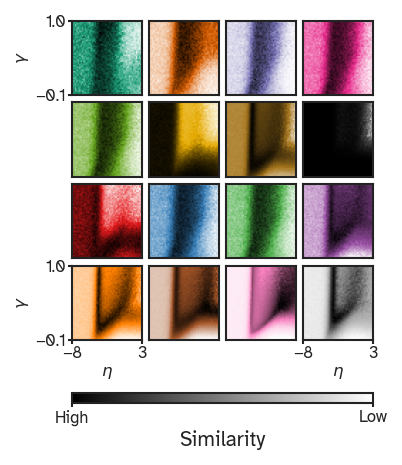

In [33]:
all_dist_measures = all_dist_measures
        
n_methods = len(all_dist_measures[::-1])
n_cols = 4
n_rows = int(np.ceil(n_methods / n_cols))

image_size_in_cm = 6
fontsize = 8
# Calculate height to maintain roughly square subplots
height = image_size_in_cm * (n_rows / n_cols) 

# Use constrained_layout instead of tight_layout
fig, axes = plt.subplots(n_rows, n_cols, 
                            figsize=viz.cm_to_inch((image_size_in_cm, height)),
                            dpi=150,
                            squeeze=True,
                            constrained_layout=False  # We'll handle layout manually
                            )

axes = axes.flatten()

for idx, mode in enumerate(all_dist_measures):
    ax = axes[idx]
    
    cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
        f'custom_cmap_{mode}', 
        [
            "black",
            metric_colors[mode], 
            "white", 
         ]
    )

    scatter = ax.imshow(matrices_of_metrics[mode], # np.log(matrices_of_metrics[mode]), 
                        cmap=cmap, 
                       aspect='auto',
                       extent=[
                           df["eta"].min(), df["eta"].max(),
                           df["gamma"].min(), df["gamma"].max()
                       ])
    
    # Set ticks
    if (idx % n_cols == 0 and idx // n_cols == n_rows -1): 
        ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
        ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
        ax.set_xlabel(r"$\eta$", fontsize=fontsize)
        ax.set_ylabel(r"$\gamma$", fontsize=fontsize)
    elif idx == 0: 
        ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
        ax.set_xticks([]) 
        ax.set_ylabel(r"$\gamma$", fontsize=fontsize)
    elif idx == len(all_dist_measures[::-1]) -1: 
        ax.set_yticks([])
        ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
        ax.set_xlabel(r"$\eta$", fontsize=fontsize)
    else: 
        ax.set_yticks([])
        ax.set_xticks([])

# Hide unused subplots
for idx in range(n_methods, len(axes)):
    axes[idx].axis('off')

# Adjust spacing manually to leave room for colorbar at bottom
plt.subplots_adjust(left=0.1, right=0.95, bottom=0.08, top=0.98, wspace=0.1, hspace=0.1)

# Get positions AFTER subplots_adjust
x_min = np.min([ax.get_position().x0 for ax in axes[:n_methods]])
x_max = np.max([ax.get_position().x1 for ax in axes[:n_methods]])
y_min = np.min([ax.get_position().y0 for ax in axes[:n_methods]])

# Add colorbar in the reserved space at bottom
cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
        f'custom_cmap_colorbar', 
        ["black", "white"])
norm = plt.Normalize(vmin=0, vmax=10)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Position colorbar below the plots
cbar_ax = fig.add_axes([x_min, -0.1, x_max - x_min, 0.03])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Similarity")
cbar.ax.tick_params(labelsize=8)
cbar.ax.set_xticks([0, 10], labels=["High", "Low"])

# Save FIRST, then show
plt.savefig(output_path / "sixteen_subplots_colored.pdf", bbox_inches='tight')
print(output_path / "sixteen_subplots_colored.pdf")
plt.show()

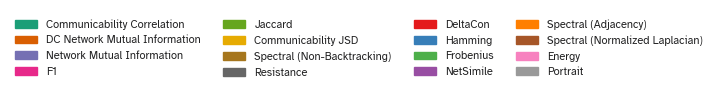

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/05_mst_animal_0/figures_manuscript_apdx/method_legend_colored.pdf


In [34]:
fig = plt.figure(figsize=(9, 1))  # Adjust size as needed
ax = fig.add_subplot(111)

# sorted_data = results_df[metric].sort_values()

# Create legend handles
handles = [patches.Patch(color=metric_colors[name], label=method_names[name]) 
           for name in all_dist_measures]

# Add legend
legend = ax.legend(handles=handles, loc='center', 
                   ncol=4, 
                #    fontsize=12, 
                   frameon=False)

# Hide the axes
ax.axis('off')

# plt.tight_layout()

plt.savefig(output_path / "method_legend_colored.pdf")
plt.show()
print(output_path / "method_legend_colored.pdf")

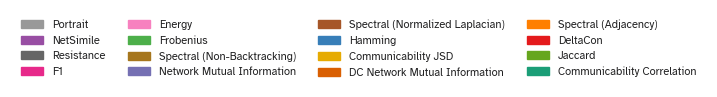

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/05_mst_animal_0/figures_manuscript_apdx/method_legend_colored.pdf


In [35]:
# reorder smartly: 

reordered_legend = [0, 4, 8, 12,
                    1, 5, 9, 13,
                    2, 6, 10, 14,
                    3, 7, 11, 15]


fig = plt.figure(figsize=(9, 1))  # Adjust size as needed
ax = fig.add_subplot(111)

# sorted_data = results_df[metric].sort_values()

# Create legend handles
handles = [patches.Patch(color=metric_colors[all_dist_measures[i]], label=method_names[all_dist_measures[i]]) 
           for i in reordered_legend[::-1]]

# Add legend
legend = ax.legend(handles=handles, loc='center', 
                   ncol=4, 
                #    fontsize=12, 
                   frameon=False)

# Hide the axes
ax.axis('off')

# plt.tight_layout()

plt.savefig(output_path / "method_legend_colored.pdf")
plt.show()
print(output_path / "method_legend_colored.pdf")

In [36]:
# fig = plt.figure(figsize=(9, 1))  # Adjust size as needed
# ax = fig.add_subplot(111)

# # sorted_data = results_df[metric].sort_values()

# # Create legend handles
# handles = [patches.Patch(color=metric_colors[name], label=method_names[name]) 
#            for name in all_dist_measures]

# # Add legend
# legend = ax.legend(handles=handles, loc='center', 
#                    ncol=4, 
#                 #    fontsize=12, 
#                    frameon=False)

# # Hide the axes
# ax.axis('off')

# # plt.tight_layout()

# plt.savefig(output_path / "method_legend_colored.pdf")
# plt.show()
# print(output_path / "method_legend_colored.pdf")

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/05_mst_animal_0/figures_manuscript_apdx/correlation_heatmap_clustered.pdf


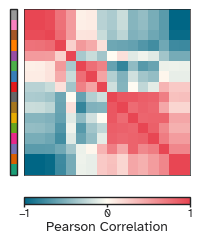

In [37]:
# Create figure with dendrogram
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))

cmap_for_corr = default_cmaps["db_bw_lr"]
thickness_bars = 0.03
distance_between_bar_and_corr_heatmap = 0.03

# Add heatmap - leave more room at bottom for colorbar
ax_heatmap = fig.add_axes([0.22, 0.15, 0.7, 0.75])
sns.heatmap(clustered_corr, annot=False, 
            cmap=cmap_for_corr, 
            square=True,
            cbar=False, 
            ax=ax_heatmap, 
            )

# Add spines
for spine in ax_heatmap.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)

# Get xticklabels, and replace them with their corresponding method names
method_names_arr = [method_names[method] for method in all_dist_measures]
method_colors_arr = [metric_colors[method] for method in all_dist_measures]
ax_heatmap.set_yticklabels([])
ax_heatmap.set_xticklabels([])

ax_heatmap.set_xlabel(None)
ax_heatmap.set_ylabel(None)

# Remove the small "ticks"
ax_heatmap.tick_params(top=False, right=False, bottom=False, left=False)

ax_heatmap.invert_xaxis()
ax_heatmap.invert_yaxis()

# Get positions AFTER setting up heatmap
heatmap_pos = ax_heatmap.get_position()
highest_pos = heatmap_pos.y1
lowest_pos = heatmap_pos.y0
leftest_pos = heatmap_pos.x0
rightest_pos = heatmap_pos.x1

# Add left colorbar (method colors)
colors_for_legend = [metric_colors[m] for m in all_dist_measures] 
cax = fig.add_axes([leftest_pos - thickness_bars - distance_between_bar_and_corr_heatmap, 
                    lowest_pos, 
                    thickness_bars, 
                    highest_pos - lowest_pos])
norm = plt.Normalize(vmin=0, vmax=len(all_dist_measures))
sm = plt.cm.ScalarMappable(cmap=plt.cm.colors.ListedColormap(colors_for_legend), norm=norm)
cb = plt.colorbar(sm, cax=cax)
cb.set_ticks(ticks=[], labels=[])
cb.ax.yaxis.set_ticks_position('left')
cb.ax.yaxis.set_label_position('left')

# Add bottom colorbar (correlation values) - position with enough space for labels
cbar_ax = fig.add_axes([leftest_pos, 
                        0.05,  # Position with space below for labels
                        rightest_pos - leftest_pos, 
                        thickness_bars])
norm = plt.Normalize(vmin=clustered_corr.values.min(), vmax=clustered_corr.values.max())
sm = plt.cm.ScalarMappable(cmap=cmap_for_corr, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Pearson Correlation') 
cbar.set_ticks([-1, 0, 1])
cbar.ax.tick_params(labelsize=8)

# Save with proper bounding box
plt.savefig(output_path / "correlation_heatmap_clustered.pdf", bbox_inches='tight') # , pad_inches=0.1)
print(output_path / "correlation_heatmap_clustered.pdf")
plt.show()

# The right one! See the flipped axes...

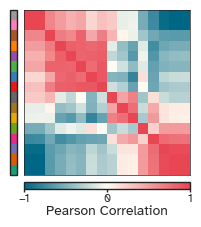

In [38]:
# Create figure with dendrogram
fig = plt.figure(figsize=viz.cm_to_inch((6,6))) # (16, 14)


cmap_for_corr = default_cmaps["db_bw_lr"] # black_white_map, # default_cmaps["db_bw_lr"], # 'RdBu_r'
thickness_bars = 0.03
distance_between_bar_and_corr_heatmap = 0.03

# Add heatmap
ax_heatmap = fig.add_axes([0.22, 0.1, 0.7, 0.8])
sns.heatmap(clustered_corr, annot=False, # True, fmt='.2f', annot_kws={'size': 8},
            cmap=cmap_for_corr, 
            # center=0, vmin=-1, vmax=1, 
            square=True,
            cbar=False, 
            # cbar_kws={'label': 'Pearson Correlation'},
            ax=ax_heatmap, 
            # linewidths=0.5
            )

# Add spines
for spine in ax_heatmap.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)

# Get xticklabels, and replace them with their corresponding method names
method_names_arr = [method_names[method] for method in all_dist_measures] # loaded_methods] 
method_colors_arr = [metric_colors[method] for method in all_dist_measures] # loaded_methods]
# .get(name, name) for name in clustered_corr.index]
ax_heatmap.set_yticklabels([]) # method_names_arr) # , rotation=45, ha='right')
ax_heatmap.set_xticklabels([])# False) # []) # method_names_arr) # , rotation=0)

# new_colors = [metric_colors.get(name) for name in methods_for_gridplot]
# print(corr_matrix.shape, new_colors)
ax_heatmap.set_xlabel(None)
ax_heatmap.set_ylabel(None)

# Get upper corner of heatmap for positioning dendrogram
heatmap_pos = ax_heatmap.get_position()


###############

# Get positions
highest_pos = ax_heatmap.get_position().y1
lowest_pos = ax_heatmap.get_position().y0

leftest_pos = ax_heatmap.get_position().x0
rightest_pos = ax_heatmap.get_position().x1

# Add colorbar on left side
#
# # cax = fig.add_axes([0.02, 0.25, 0.03, 0.65])
# cax = fig.add_axes([heatmap_pos.x0 - 0.05, heatmap_pos.y0, 0.03, heatmap_pos.height])

# norm = plt.Normalize(vmin=0, vmax=len(method_colors_arr))
# sm = plt.cm.ScalarMappable(cmap=plt.cm.colors.ListedColormap(method_colors_arr), norm=norm)
# cb = plt.colorbar(sm, cax=cax)
# cb.set_ticks([])
colors_for_legend = [metric_colors[m] for m in all_dist_measures] # loaded_methods] # method_colors_arrall_methods_sorted_for_legend]
#
cax = fig.add_axes([leftest_pos - thickness_bars - distance_between_bar_and_corr_heatmap, lowest_pos, thickness_bars, highest_pos - lowest_pos])
norm = plt.Normalize(vmin=0, vmax=len(all_dist_measures))
sm = plt.cm.ScalarMappable(cmap=plt.cm.colors.ListedColormap(colors_for_legend), norm=norm)
cb = plt.colorbar(sm, cax=cax)
cb.set_ticks(
    ticks=[], 
    # ticks=[i + 0.5 for i in range(len(names_for_legend))], 
    labels=[])# names_for_legend)

cb.ax.yaxis.set_ticks_position('left')
cb.ax.yaxis.set_label_position('left')


################


# remove the small "ticks"
ax_heatmap.tick_params(top=False, right=False, bottom=False, left=False)

# cbar
# Add cbar that is as high as the heatmap. So get the lowest and highest position of the heatmap
highest_pos = ax_heatmap.get_position().y1
lowest_pos = ax_heatmap.get_position().y0

leftest_pos = ax_heatmap.get_position().x0
rightest_pos = ax_heatmap.get_position().x1
buffer = 0.01
# cbar_ax = fig.add_axes([1, 0.1, 0.02, 0.8])
# cbar_ax = fig.add_axes([rightest_pos + buffer, lowest_pos, 0.02, highest_pos - lowest_pos])
cbar_ax = fig.add_axes([leftest_pos, lowest_pos - thickness_bars - distance_between_bar_and_corr_heatmap, rightest_pos - leftest_pos, thickness_bars]) # highest_pos - lowest_pos])
norm = plt.Normalize(vmin=clustered_corr.values.min(), vmax=clustered_corr.values.max())
sm = plt.cm.ScalarMappable(cmap=cmap_for_corr, norm=norm) # default_cmaps["db_bw_lr"], norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Pearson Correlation') 

# only add ticks for -1, 0, 1
cbar.set_ticks([-1, 0, 1])
cbar.ax.tick_params(labelsize=8)

plt.savefig(output_path / "correlation_heatmap_clustered_with_dendrogram_and_colorbar.pdf")
plt.show()


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/05_mst_animal_0/figures_manuscript_apdx/correlation_heatmap_clustered_only_heatmap.pdf


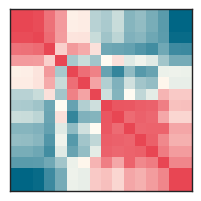

In [39]:
# Create figure with dendrogram
fig, ax_heatmap = plt.subplots(1, 1, figsize=viz.cm_to_inch((6,6)))

cmap_for_corr = default_cmaps["db_bw_lr"]
# thickness_bars = 0.03
# distance_between_bar_and_corr_heatmap = 0.03

# Add heatmap - leave more room at bottom for colorbar
# ax_heatmap = fig.add_axes([0.22, 0.15, 0.7, 0.75])
sns.heatmap(clustered_corr, annot=False, 
            cmap=cmap_for_corr, 
            square=True,
            cbar=False, 
            ax=ax_heatmap, 
            )

# Add spines
for spine in ax_heatmap.spines.values():
    spine.set_visible(True)
    # spine.set_linewidth(0.5)

# Get xticklabels, and replace them with their corresponding method names
method_names_arr = [method_names[method] for method in all_dist_measures]
method_colors_arr = [metric_colors[method] for method in all_dist_measures]
ax_heatmap.set_yticklabels([])
ax_heatmap.set_xticklabels([])

ax_heatmap.set_xlabel(None)
ax_heatmap.set_ylabel(None)

# Remove the small "ticks"
ax_heatmap.tick_params(top=False, right=False, bottom=False, left=False)

ax_heatmap.invert_xaxis()
ax_heatmap.invert_yaxis()

# # Get positions AFTER setting up heatmap
# heatmap_pos = ax_heatmap.get_position()
# highest_pos = heatmap_pos.y1
# lowest_pos = heatmap_pos.y0
# leftest_pos = heatmap_pos.x0
# rightest_pos = heatmap_pos.x1

# # Add left colorbar (method colors)
# colors_for_legend = [metric_colors[m] for m in all_dist_measures] 
# cax = fig.add_axes([leftest_pos - thickness_bars - distance_between_bar_and_corr_heatmap, 
#                     lowest_pos, 
#                     thickness_bars, 
#                     highest_pos - lowest_pos])
# norm = plt.Normalize(vmin=0, vmax=len(all_dist_measures))
# sm = plt.cm.ScalarMappable(cmap=plt.cm.colors.ListedColormap(colors_for_legend), norm=norm)
# cb = plt.colorbar(sm, cax=cax)
# cb.set_ticks(ticks=[], labels=[])
# cb.ax.yaxis.set_ticks_position('left')
# cb.ax.yaxis.set_label_position('left')

# # Add bottom colorbar (correlation values) - position with enough space for labels
# cbar_ax = fig.add_axes([leftest_pos, 
#                         0.05,  # Position with space below for labels
#                         rightest_pos - leftest_pos, 
#                         thickness_bars])
# norm = plt.Normalize(vmin=clustered_corr.values.min(), vmax=clustered_corr.values.max())
# sm = plt.cm.ScalarMappable(cmap=cmap_for_corr, norm=norm)
# sm.set_array([])

# cbar = plt.colorbar(sm, cax=cbar_ax, orientation='horizontal')
# cbar.set_label('Pearson Correlation') 
# cbar.set_ticks([-1, 0, 1])
# cbar.ax.tick_params(labelsize=8)

# Save with proper bounding box
plt.savefig(output_path / "correlation_heatmap_clustered_only_heatmap.pdf", bbox_inches='tight') # , pad_inches=0.1)
print(output_path / "correlation_heatmap_clustered_only_heatmap.pdf")
plt.show()

# The right one! See the flipped axes...

In [40]:
# Create figure with dendrogram
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))

# Add left colorbar (method colors)
colors_for_legend = [metric_colors[m] for m in all_dist_measures] 
cax = fig.add_axes([0, 0, 0.03, 1])  # leftest_pos - thickness_bars - distance_between_bar_and_corr_heatmap, 
                    # lowest_pos, 
                    # thickness_bars, 
                    # highest_pos - lowest_pos])
norm = plt.Normalize(vmin=len(all_dist_measures), vmax=0)
sm = plt.cm.ScalarMappable(cmap=plt.cm.colors.ListedColormap(colors_for_legend), norm=norm)
cb = plt.colorbar(sm, cax=cax)
cb.set_ticks(ticks=[], labels=[])
cb.ax.yaxis.set_ticks_position('left')
cb.ax.yaxis.set_label_position('left')

# Save with proper bounding box
plt.savefig(output_path / "cbar_methods.pdf", bbox_inches='tight') # , pad_inches=0.1)
print(output_path / "cbar_methods.pdf")
plt.show()

# The right one! See the flipped axes...

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/05_mst_animal_0/figures_manuscript_apdx/cbar_methods.pdf


In [41]:
def get_top_networks_distribution(dataset_name, experiment_name, mode='portrait', top_n=20):

    # Paths
    base_path = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset_name}/{experiment_name}"
    summary_path = f"{base_path}/summary_indiv_{mode}_for_exp_{experiment_name}.csv"
    networks_path = f"{base_path}/generated_networks"
    
    # Load summary data
    df = pd.read_csv(summary_path)
    # print(f"Loaded summary with columns: {list(df.columns)}")
    
    # Identify metric column (excluding metadata columns)
    metadata_cols = ["eta", "gamma", "network_index", "filename", "id"]
    metric_cols = [col for col in df.columns if col not in metadata_cols]
    
    if not metric_cols:
        raise ValueError(f"No metric column found in {df.columns}")
    
    metric_col = metric_cols[0]
    print(f"Using metric column: '{metric_col}'")
    
    # Select top N networks (lowest values = best)
    df_sorted = df.nsmallest(top_n, metric_col)
    # print(f"\nSelected top {top_n} networks with {metric_col} range: "
    #       f"[{df_sorted[metric_col].min():.6f}, {df_sorted[metric_col].max():.6f}]")
        
    # Load distance matrix (schaefer) 
    distance_matrix_file = "/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/data/preprocessed/lexis_data/02_distance_matrices/distance_matrix_100.npy"
    distance_matrix = np.load(distance_matrix_file)
    
    
    # Load networks and calculate degree distributions
    all_degrees = []
    all_distances = []
    
    for idx, row in df_sorted.iterrows():
        # Construct filename
        network_file = Path(networks_path) / row['filename']
        
        # Load network
        network = np.load(network_file)
        
        # Extract adjacency matrix (assuming shape is (1, 100, 100))
        if network.shape[0] == 1:
            adj_matrix = network[0]
        else:
            adj_matrix = network
        
        # Calculate degree for each node
        degrees = np.sum(adj_matrix, axis=1)
        all_degrees.extend(degrees)
        
        # get all distances, remove zeros 
        distances_for_this_network = (distance_matrix*network).flatten()
        all_distances.extend(distances_for_this_network[distances_for_this_network > 0])
        
    # Convert to numpy array
    all_degrees = np.array(all_degrees)
    all_distances = np.array(all_distances)
    # print(f"\nCollected {len(all_degrees)} node degrees from {len(df_sorted)} networks")
    # print(f"Degree statistics: mean={all_degrees.mean():.2f}, "
    #       f"std={all_degrees.std():.2f}, "
    #       f"min={all_degrees.min()}, max={all_degrees.max()}")   

    # Get distance matrix values (excluding zeros on diagonal)
    # all_distances = distance_matrix[distance_matrix > 0]
    
    return all_degrees, all_distances

distributions_degree = {}
distributions_distances = {}
for mode in all_dist_measures: 
    distributions_degree[mode], distributions_distances[mode] = get_top_networks_distribution(dataset_name, experiment_name, mode=mode, top_n=20)


Using metric column: 'CommCorr_subject_0'


FileNotFoundError: [Errno 2] No such file or directory: '/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/data/preprocessed/lexis_data/02_distance_matrices/distance_matrix_100.npy'

In [ ]:
# Human distributions 
human_connectomes = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/data/preprocessed/lexis_data/01_connectomes/00_individual_connectomes_bin.npy")
distance_matrix = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/data/preprocessed/lexis_data/02_distance_matrices/distance_matrix_100.npy")

all_degrees = []
all_distances = []

for A in human_connectomes: 
    # Calculate degree for each node
    degrees = np.sum(A, axis=1)
    all_degrees.extend(degrees)
    
    # get all distances, remove zeros 
    distances_for_this_network = (distance_matrix*A).flatten()
    all_distances.extend(distances_for_this_network[distances_for_this_network > 0])

# Convert to numpy array
human_degrees = np.array(all_degrees)
human_distances = np.array(all_distances)

distributions_distances['human'] = human_distances
distributions_degree['human'] = human_degrees

human_distances

array([ 44.18144407,  32.06243908,  63.59245238, ..., 116.65333257,
        17.08800749,  16.61324773])

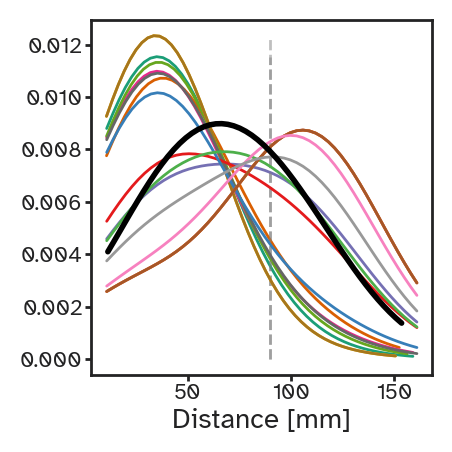

In [ ]:
import scipy.ndimage as ndimage

# plot degree distributions (smoothed) 
fig, ax = plt.subplots(figsize=viz.cm_to_inch((6, 6)), dpi=200)

max_value_for_line = 0 

for mode, distances in distributions_distances.items():
    
    if mode not in all_dist_measures and not mode == 'human': 
        continue
    
    # Create histogram to get counts
    number_bins = 50
    counts, bins = np.histogram(distances, bins=number_bins, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Add padding to bin_centers (linear expansion)
    bin_centers = np.array([bins[0] - (bins[1]-bins[0])*i for i in range(20,0,-1)] + list(bin_centers) + 
                           [bins[-1] + (bins[1]-bins[0])*i for i in range(1,21)])

    # padded_counts = []
    # for count in counts: 
    count = np.array([0]*20 + list(counts) + [0]*20)
    count = ndimage.gaussian_filter1d(count, sigma=10) 
    #     padded_counts.append(count)

    if count.max() > max_value_for_line:
        max_value_for_line = count.max()
        ax.vlines(x=90, 
                  ymin=0, ymax=max_value_for_line, 
                  color="gray", 
                  linestyle='--', alpha=0.5)

    # # Smooth the histogram with Gaussian filter
    # # smoothed_counts = ndimage.gaussian_filter1d(padded_counts, sigma=10) # 2
    
        # Plot smoothed curve
    ax.plot(bin_centers[20:-20], 
            count[20:-20],
            label=method_names[mode] if mode != 'human' else 'Human Connectomes',
            color=metric_colors[mode] if mode != 'human' else 'black',
            linewidth=2 if mode == "human" else 1
            )

plt.xlabel('Distance [mm]')
plt.ylabel("")
# plt.legend(fontsize=8, bbox_to_anchor=(1, 1), frameon=False)
plt.tight_layout()
plt.show()

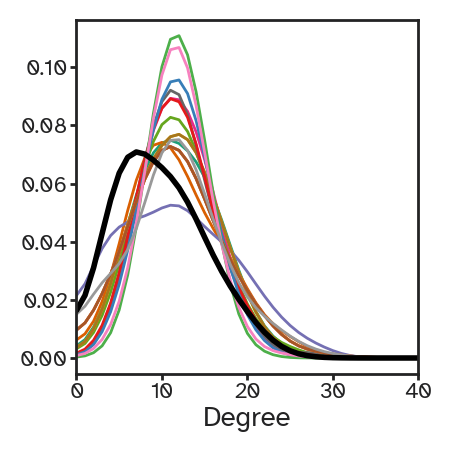

In [ ]:
import scipy.ndimage as ndimage

# plot degree distributions (smoothed) 
fig, ax = plt.subplots(figsize=viz.cm_to_inch((6, 6)), dpi=200)

for mode, degrees in distributions_degree.items():
    
    if mode not in all_dist_measures and not mode == 'human': 
        continue
    
    # Create bins that always have steps of one and start quantity 0
    max_degree = 100
    bins = np.arange(0, max_degree + 2, step=1) - 0.5  # bins of width 1 centered on integers
    
    # Create histogram to get counts
    counts, bins = np.histogram(degrees, bins=bins, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    count = ndimage.gaussian_filter1d(counts, sigma=2) 
    
    # Plot smoothed curve
    ax.plot(bin_centers, 
            count,
            label=method_names[mode] if mode != 'human' else 'Human Connectomes',
            color=metric_colors[mode] if mode != 'human' else 'black',
            linewidth=1 if mode != 'human' else 2
            )

plt.xlim(0, 40)
    

plt.xlabel('Degree')
plt.ylabel("")
# plt.legend()
plt.tight_layout()
plt.show()

# Degeneration

In [ ]:
from typing import Dict, List

# Base directory for your chaos analysis results
base_dir = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis"
output_dir = f"{base_dir}/plots"
Path(output_dir).mkdir(parents=True, exist_ok=True)


# degeneration_x_label_descriptor = "Degeneration Level\n(Consensus to Chaos)" # 'Step (0=Consensus -> Max=Chaos)'
# degeneration_x_label_descriptor = "Degeneration: Consensus to Chaos" # 'Step (0=Consensus -> Max=Chaos)'
degeneration_x_label_descriptor = "Increasing Degeneration" # : Consensus to Chaos" # 'Step (0=Consensus -> Max=Chaos)'



Plotting comparison...
Portrait
Energy
Spectral (Normalized Laplacian)
Spectral (Adjacency)
NetSimile
Frobenius
Hamming
DeltaCon
Resistance
Spectral (Non-Backtracking)
Communicability JSD
Jaccard
F1
Network Mutual Information
DC Network Mutual Information
Communicability Correlation
Saved comparison plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_comparison_all_metrics.pdf


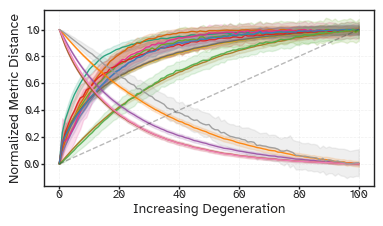

In [ ]:
def plot_multiple_metrics_comparison(
    csv_paths: Dict[str, str],
    output_path: str = None,
    figsize_cm: tuple = (20, 12),
    normalize: bool = True
):
    """
    Compare multiple metrics on the same plot.
    """
    fig, ax = plt.subplots(figsize=viz.cm_to_inch(figsize_cm))
    
    for idx, (metric_name, csv_path) in enumerate(csv_paths.items()):
        # Load data
        df = pd.read_csv(csv_path)
        
        # Calculate mean trajectory
        df_summary = df.groupby('step')['metric_value'].agg(['mean', 'std']).reset_index()
        
        # Normalize if requested
        if normalize:
            min_val = df_summary['mean'].min()
            max_val = df_summary['mean'].max()
            if max_val > min_val:  # Avoid division by zero
                df_summary['mean_norm'] = (df_summary['mean'] - min_val) / (max_val - min_val)
                df_summary['std_norm'] = df_summary['std'] / (max_val - min_val)
                y_col = 'mean_norm'
                std_col = 'std_norm'
            else:
                y_col = 'mean'
                std_col = 'std'
        else:
            y_col = 'mean'
            std_col = 'std'
        
        # Plot
        color = metric_colors[metric_name]
        ax.plot(
            df_summary['step'],
            df_summary[y_col],
            color=color,
            label=method_names[metric_name],
            alpha=0.9
        )

        print(method_names[metric_name])
        # Optional: add std band
        ax.fill_between(
            df_summary['step'],
            df_summary[y_col] - df_summary[std_col],
            df_summary[y_col] + df_summary[std_col],
            alpha=0.15,
            color=color
        )
    
    # Formatting
    ax.set_xlabel(degeneration_x_label_descriptor)
    if normalize:
        ax.set_ylabel('Normalized Metric Distance') # , fontsize=11)
    else:
        ax.set_ylabel('Metric Distance')

    # ax.set_title('Comparison of Metrics During Network Degradation', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Add diagonal line for reference
    max_x = df_summary['step'].max()
    ax.plot([0, max_x], [0, 1], 'k--', alpha=0.3, linewidth=1)

    # plt.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1,1))
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Saved comparison plot to: {output_path}")
    else:
        plt.show()
    
    
    # plt.close()
    plt.show()
    
    return fig, ax



# Plot comparison of all metrics
print("\nPlotting comparison...")
csv_paths = {}
for metric in all_dist_measures: 
    csv_path = f"{base_dir}/chaos_analysis_{metric}.csv"
    if Path(csv_path).exists():
        csv_paths[metric] = csv_path

if csv_paths:
    plot_multiple_metrics_comparison(
        csv_paths=csv_paths,
        output_path=f"{output_dir}/chaos_comparison_all_metrics.pdf",
        figsize_cm=(10,6), # 6),
        normalize=True
    )
    



In [ ]:
# Plotting comparison of top five metrics only

selected_methods_top_five = [] 
csv_paths = {}
for metric in selected_methods_top_five: 
    csv_path = f"{base_dir}/chaos_analysis_{metric}.csv"
    if Path(csv_path).exists():
        csv_paths[metric] = csv_path

if csv_paths:
    plot_multiple_metrics_comparison(
        csv_paths=csv_paths,
        output_path=f"{output_dir}/chaos_comparison_all_metrics_only_top_five.pdf",
        figsize_cm=(10,6), # 6),
        normalize=True
    )
    



# Variance and timing


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/figures_manuscript/sixteen_subplots_variance.pdf


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_77395/2886959983.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


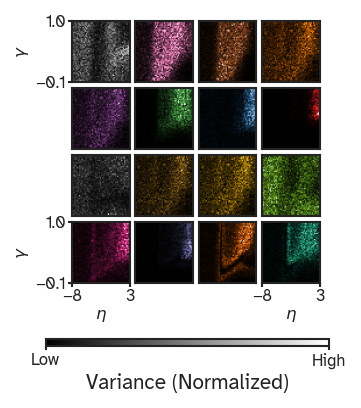

In [ ]:
# Calculate variance for each metric across networks at each eta-gamma point
variance_matrices_of_metrics = {}

for idx, mode in enumerate(all_dist_measures):
    path = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset_name}/{experiment_name}/summary_indiv_{mode}_for_exp_{experiment_name}.csv"
    df = pd.read_csv(path)
    
    # Get the metric column
    metric_col = [col for col in df.columns if col not in ["eta", "gamma", "network_index", "filename", "id"]]
    if not metric_col:
        raise ValueError(f"No metric column found in {df.columns}")
    
    # Round eta and gamma
    df['eta'] = df['eta'].round(2)
    df['gamma'] = df['gamma'].round(2)
    filtering_df['eta'] = filtering_df['eta'].round(2)
    filtering_df['gamma'] = filtering_df['gamma'].round(2)

    # Merge and filter if needed
    if "no" in experiment_name:
        df = df.merge(filtering_df[['eta', 'gamma', 'n_connected_components']], 
                    on=['eta', 'gamma'], 
                    how='left')
        df = df[df['n_connected_components'] <= 1]
    else: 
        df = df.merge(filtering_df[['eta', 'gamma']], 
                    on=['eta', 'gamma'], 
                    how='left')

    # Turn df into a pivot table - compute VARIANCE instead of mean
    df_pivot = df.pivot_table(index='gamma', columns='eta', values=metric_col[0], aggfunc='var')

    # Min-max normalize the variance values to [0, 1]
    df_pivot = (df_pivot - df_pivot.min().min()) / (df_pivot.max().max() - df_pivot.min().min())
    
    # Store the matrix as a numpy array
    matrix = df_pivot.values[::-1]
    
    variance_matrices_of_metrics[mode] = matrix

# Create the grid plot for variance
n_methods = len(all_dist_measures[::-1])
n_cols = 4
n_rows = int(np.ceil(n_methods / n_cols))

image_size_in_cm = 6
fontsize = 8
height = image_size_in_cm * (n_rows / n_cols) 

fig, axes = plt.subplots(n_rows, n_cols, 
                            figsize=viz.cm_to_inch((image_size_in_cm, height)),
                            dpi=150,
                            squeeze=True)

axes = axes.flatten()

for idx, mode in enumerate(all_dist_measures[::-1]):
    ax = axes[idx]
    
    cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
        f'custom_cmap_{mode}', 
        [
            "black",
            metric_colors[mode], 
            "white", 
        ]
    )

    scatter = ax.imshow(variance_matrices_of_metrics[mode], 
                        cmap=cmap, 
                       aspect='auto',
                       extent=[
                           df["eta"].min(), df["eta"].max(),
                           df["gamma"].min(), df["gamma"].max()
                       ])
    
    # Set ticks
    if (idx % n_cols == 0 and idx // n_cols == n_rows -1): 
        ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
        ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
        ax.set_xlabel(r"$\eta$", fontsize=fontsize)
        ax.set_ylabel(r"$\gamma$", fontsize=fontsize)
    elif idx == 0: 
        ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
        ax.set_xticks([]) 
        ax.set_ylabel(r"$\gamma$", fontsize=fontsize)
    elif idx == len(all_dist_measures[::-1]) -1: 
        ax.set_yticks([])
        ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
        ax.set_xlabel(r"$\eta$", fontsize=fontsize)
    else: 
        ax.set_yticks([])
        ax.set_xticks([])

# Hide unused subplots
for idx in range(n_methods, len(axes)):
    axes[idx].axis('off')

# Get min and max location of the corners of the subplots
x_min = np.min([ax.get_position().x0 for ax in axes]) + 0.025
x_max = np.max([ax.get_position().x1 for ax in axes]) + 2 * 0.025
y_min = np.min([ax.get_position().y0 for ax in axes])
y_max = np.max([ax.get_position().y1 for ax in axes])

# Add one shared colorbar below all subplots
cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
        f'custom_cmap_colorbar', 
        [
            "black",
            "white", 
         ])
norm = plt.Normalize(vmin=0, vmax=10)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([x_min, 0, x_max - x_min, 0.02])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Variance (Normalized)")
cbar.ax.tick_params(labelsize=8)
cbar.ax.set_xticks([0, 10], labels=['Low', 'High'])

plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.1)

plt.savefig(output_path / "sixteen_subplots_variance.pdf")
print(output_path / "sixteen_subplots_variance.pdf")
plt.show()


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/figures_manuscript/timing_16.pdf


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_77395/2415522018.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


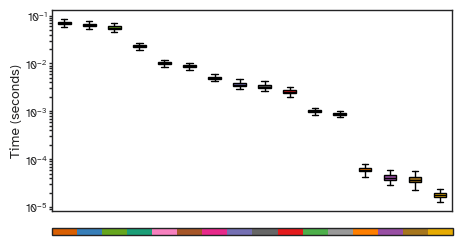

In [ ]:
fig, ax = plt.subplots(figsize=viz.cm_to_inch((12, 6)))

bp = ax.boxplot(
    timing_data,
    patch_artist=True,
    showfliers=False,
)

# Color boxes
for patch, method in zip(bp['boxes'], method_key_names_ordered):
    patch.set_facecolor(metric_colors[method])

# Median lines
for median in bp['medians']:
    median.set_color('black')

ax.set_ylabel('Time (seconds)')
ax.set_yscale('log')
ax.set_xticks([])  # remove x ticks entirely


pos = ax.get_position()

bar_height = 0.03
gap = 0.1

cax = fig.add_axes([
    pos.x0 - 0.005, # - bar_width - gap,  # left of boxplot
    pos.y0 - bar_height - gap, # below boxplot
    pos.width + 0.075, # + gap, # + 0.015,  # same width as boxplot
    bar_height
])

colors_for_legend = [metric_colors[m] for m in method_key_names_ordered]

cmap = mpl.colors.ListedColormap(colors_for_legend)
norm = mpl.colors.BoundaryNorm(
    boundaries=np.arange(len(colors_for_legend) + 1),
    ncolors=len(colors_for_legend)
)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cb = fig.colorbar(sm, cax=cax, orientation='horizontal')

cb.set_ticklabels([]) 
cb.ax.yaxis.set_visible(False)
cb.ax.xaxis.set_visible(False)

plt.tight_layout()

plt.savefig(output_path / "timing_16.pdf")
print(output_path / "timing_16.pdf")

In [ ]:
timing_results = {}
for times, method in zip(timing_data, method_key_names_ordered):
    mean_time = np.mean(times)
    std_time = np.std(times)
    print(f"{method_names[method]:<20}: {mean_time:.4f} ± {std_time:.4f} seconds")
    # store results in dictionary
    timing_results[method] = (mean_time, std_time)

for times, method in zip(timing_data, method_key_names_ordered):
    print(f"{method}: {len(times)} runs)") # , times: {times}")

Energy              : 0.0717 ± 0.0063 seconds
Spectral (Non-Backtracking): 0.0675 ± 0.0163 seconds
NetSimile           : 0.0572 ± 0.0106 seconds
Portrait            : 0.0235 ± 0.0021 seconds
DC Network Mutual Information: 0.0102 ± 0.0009 seconds
Network Mutual Information: 0.0088 ± 0.0009 seconds
Spectral (Adjacency): 0.0050 ± 0.0005 seconds
Spectral (Normalized Laplacian): 0.0037 ± 0.0031 seconds
DeltaCon            : 0.0034 ± 0.0032 seconds
Resistance          : 0.0027 ± 0.0022 seconds
Communicability JSD : 0.0010 ± 0.0002 seconds
Communicability Correlation: 0.0009 ± 0.0002 seconds
F1                  : 0.0001 ± 0.0000 seconds
Jaccard             : 0.0000 ± 0.0001 seconds
Hamming             : 0.0000 ± 0.0001 seconds
Frobenius           : 0.0000 ± 0.0000 seconds
energy: 25000 runs)
netrd_non_backtracking_spectral: 25000 runs)
net_simile: 25000 runs)
portrait: 25000 runs)
dc_network_mutual_information: 25000 runs)
network_mutual_information: 25000 runs)
spectral_distance_adjacency: 2

In [ ]:
# generate latex table from timing_results
print("\\begin{center}")
print("     \\begin{tabular}{l c}")
print("         \\hline")
print("         Method & Time (milliseconds, mean $\pm$ std) \\\\")
print("         \\hline")
for method in method_key_names_ordered:
    mean_time, std_time = timing_results[method]
    print(f"        {method_names[method]:<20} & {mean_time * 1000:.4f} $\\pm$ {std_time * 1000:.4f} \\\\")
print("         \\hline")
print("     \\end{tabular}")
print("\\end{center}")

\begin{center}
     \begin{tabular}{l c}
         \hline
         Method & Time (milliseconds, mean $\pm$ std) \\
         \hline
        Energy               & 71.7234 $\pm$ 6.3094 \\
        Spectral (Non-Backtracking) & 67.4767 $\pm$ 16.2705 \\
        NetSimile            & 57.2284 $\pm$ 10.6295 \\
        Portrait             & 23.4647 $\pm$ 2.1377 \\
        DC Network Mutual Information & 10.1781 $\pm$ 0.9333 \\
        Network Mutual Information & 8.7744 $\pm$ 0.8688 \\
        Spectral (Adjacency) & 4.9728 $\pm$ 0.5206 \\
        Spectral (Normalized Laplacian) & 3.7044 $\pm$ 3.0545 \\
        DeltaCon             & 3.4371 $\pm$ 3.2493 \\
        Resistance           & 2.6676 $\pm$ 2.1617 \\
        Communicability JSD  & 1.0205 $\pm$ 0.1757 \\
        Communicability Correlation & 0.9046 $\pm$ 0.1741 \\
        F1                   & 0.0630 $\pm$ 0.0205 \\
        Jaccard              & 0.0478 $\pm$ 0.0567 \\
        Hamming              & 0.0442 $\pm$ 0.0802 \\
        Frobe

<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:5: SyntaxWarning: invalid escape sequence '\p'
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_77395/2155447080.py:5: SyntaxWarning: invalid escape sequence '\p'
  print("         Method & Time (milliseconds, mean $\pm$ std) \\\\")


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_74196/1244884173.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/figures_manuscript/timing_16.pdf


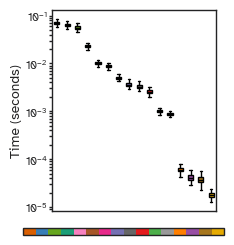

In [ ]:
fig, ax = plt.subplots(figsize=viz.cm_to_inch((6, 6)))

bp = ax.boxplot(
    timing_data,
    patch_artist=True,
    showfliers=False,
)

# Color boxes
for patch, method in zip(bp['boxes'], method_key_names_ordered):
    patch.set_facecolor(metric_colors[method])

# Median lines
for median in bp['medians']:
    median.set_color('black')

ax.set_ylabel('Time (seconds)')
ax.set_yscale('log')
ax.set_xticks([])  # remove x ticks entirely


pos = ax.get_position()

bar_height = 0.03
gap = 0.1

cax = fig.add_axes([
    pos.x0 - 0.005, # - bar_width - gap,  # left of boxplot
    pos.y0 - bar_height - gap, # below boxplot
    pos.width + 0.075, # + gap, # + 0.015,  # same width as boxplot
    bar_height
])

colors_for_legend = [metric_colors[m] for m in method_key_names_ordered]

cmap = mpl.colors.ListedColormap(colors_for_legend)
norm = mpl.colors.BoundaryNorm(
    boundaries=np.arange(len(colors_for_legend) + 1),
    ncolors=len(colors_for_legend)
)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cb = fig.colorbar(sm, cax=cax, orientation='horizontal')

cb.set_ticklabels([]) 
cb.ax.yaxis.set_visible(False)
cb.ax.xaxis.set_visible(False)

plt.tight_layout()

plt.savefig(output_path / "timing_16.pdf")
print(output_path / "timing_16.pdf")

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_74196/3553843406.py:9: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/figures_manuscript/timing_16_no_cbar.pdf


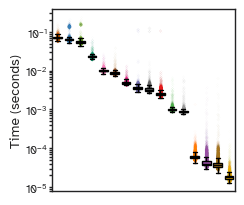

In [ ]:
fig, ax = plt.subplots(figsize=viz.cm_to_inch((6, 6)))



# Optional: overlay scatter with jitter like in your original code
for i, method in enumerate(method_key_names_ordered):
    t = timing_data[i]
    jitter = np.random.normal(loc=0, scale=0.03, size=len(t))
    ax.scatter(
        np.ones_like(t) * i + 1 + jitter,
        t,
        c=metric_colors[method], 
        s=0.005,
        alpha=0.1,
        # color='black'
        rasterized=True
    )
    
    
bp = ax.boxplot(
    timing_data,
    widths=0.75,
    patch_artist=True,
    showfliers=False,
)

# Color boxes
for patch, method in zip(bp['boxes'], method_key_names_ordered):
    patch.set_facecolor(metric_colors[method])

# Median lines
for median in bp['medians']:
    median.set_color('black')

ax.set_ylabel('Time (seconds)')
ax.set_yscale('log')
ax.set_xticks([])  # remove x ticks entirely

plt.savefig(output_path / "timing_16_no_cbar.pdf", bbox_inches='tight', dpi=300)
print(output_path / "timing_16_no_cbar.pdf")

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_74196/2016876849.py:8: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/figures_manuscript/timing_16_no_cbar.pdf


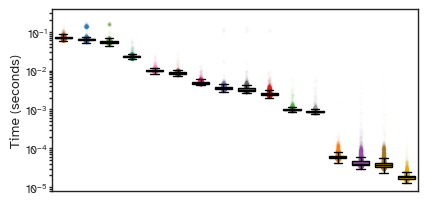

In [ ]:
fig, ax = plt.subplots(figsize=viz.cm_to_inch((12, 6)))


# Optional: overlay scatter with jitter like in your original code
for i, method in enumerate(method_key_names_ordered):
    t = timing_data[i]
    jitter = np.random.normal(loc=0, scale=0.03, size=len(t))
    ax.scatter(
        np.ones_like(t) * i + 1 + jitter,
        t,
        c=metric_colors[method], 
        s=0.005,
        alpha=0.1,
        # color='black'
        rasterized=True
    )
    
    
bp = ax.boxplot(
    timing_data,
    widths=0.75,
    patch_artist=True,
    showfliers=False,
)

# Color boxes
for patch, method in zip(bp['boxes'], method_key_names_ordered):
    patch.set_facecolor(metric_colors[method])

# Median lines
for median in bp['medians']:
    median.set_color('black')

ax.set_ylabel('Time (seconds)')
ax.set_yscale('log')
ax.set_xticks([])  # remove x ticks entirely

plt.savefig(output_path / "timing_16_no_cbar.pdf", bbox_inches='tight', dpi=300)
print(output_path / "timing_16_no_cbar.pdf")

In [ ]:
fig = plt.figure(figsize=viz.cm_to_inch((12, 6)))

cax = fig.add_axes([0,1,1,0.03])

colors_for_legend = [metric_colors[m] for m in method_key_names_ordered]

cmap = mpl.colors.ListedColormap(colors_for_legend)
norm = mpl.colors.BoundaryNorm(
    boundaries=np.arange(len(colors_for_legend) + 1),
    ncolors=len(colors_for_legend)
)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cb = fig.colorbar(sm, cax=cax, orientation='horizontal')

cb.set_ticklabels([]) 
cb.ax.yaxis.set_visible(False)
cb.ax.xaxis.set_visible(False)

plt.savefig(output_path / "cbar_timing_16.pdf", bbox_inches='tight')
print(output_path / "cbar_timing_16.pdf")

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/figures_manuscript/cbar_timing_16.pdf


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_74196/868623889.py:27: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_74196/868623889.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_74196/868623889.py:37: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipyke

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/figures_manuscript/timing_16_with_violin_and_scatter.png
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/figures_manuscript/timing_16_with_violin_and_scatter.pdf


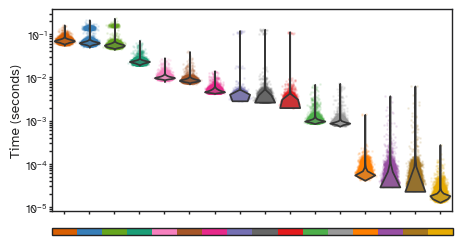

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib as mpl

# Prepare data for seaborn: convert list of arrays to a long-form DataFrame
# timing_data: list of arrays, one per method
# method_key_names_ordered: list of method names in the same order
data_list = []
for method_name, t in zip(method_key_names_ordered, timing_data):
    df_temp = pd.DataFrame({
        'Time (seconds)': t,
        'Method': method_name
    })
    data_list.append(df_temp)

df = pd.concat(data_list, ignore_index=True)

# Create figure
fig, ax = plt.subplots(figsize=viz.cm_to_inch((12, 6)))  # assuming viz.cm_to_inch is just scaling, skip for now

# Optional: overlay scatter with jitter like in your original code
for i, method in enumerate(method_key_names_ordered):
    t = timing_data[i]
    jitter = np.random.normal(loc=0, scale=0.1, size=len(t))
    ax.scatter(
        np.ones_like(t) * i + jitter,
        t,
        c=metric_colors[method], 
        s=1,
        alpha=0.1,
        # color='black'
    )
    
# Violin plot
sns.violinplot(
    x='Method',
    y='Time (seconds)',
    data=df,
    palette=metric_colors,  # dict of {method_name: color}
    cut=0,
    scale='width',
    inner=None,
    ax=ax
)



# Y-axis log scale
ax.set_yscale('log')

# Remove x-ticks labels if desired
ax.set_xticklabels([])
ax.set_xlabel(None)

ax.set_ylabel('Time (seconds)')

# --- Horizontal colorbar like in your original code ---
pos = ax.get_position()
bar_height = 0.03
gap = 0.1

cax = fig.add_axes([
    pos.x0 - 0.005,
    pos.y0 - bar_height - gap,
    pos.width + 0.075,
    bar_height
])

colors_for_legend = [metric_colors[m] for m in method_key_names_ordered]

cmap = mpl.colors.ListedColormap(colors_for_legend)
norm = mpl.colors.BoundaryNorm(
    boundaries=np.arange(len(colors_for_legend) + 1),
    ncolors=len(colors_for_legend)
)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cb = fig.colorbar(sm, cax=cax, orientation='horizontal')
cb.set_ticklabels([])
cb.ax.yaxis.set_visible(False)
cb.ax.xaxis.set_visible(False)

plt.tight_layout()
plt.savefig(output_path / "timing_16_with_violin_and_scatter.png", bbox_inches="tight", dpi=300)
print(output_path / "timing_16_with_violin_and_scatter.png")
plt.savefig(output_path / "timing_16_with_violin_and_scatter.pdf", bbox_inches="tight", dpi=300)
print(output_path / "timing_16_with_violin_and_scatter.pdf")
